# Deep Borehole Heat Exchanger (DBHE) — BVP + GITT Convergence Study
## Onshore South Louisiana Legacy Well · Insulated Tubing
### Convergence of T_ret and Q_cold with respect to NZ, dt_step, and N_eig

**Purpose:** Demonstrate that the three numerical solution parameters (NZ, dt, N_eig)
chosen for parametric sweeps and TEA analyses are numerically converged.
All physics cells (Cells 1–9) are unchanged from v5.4.
Cells 10–13 are replaced by a three-parameter convergence study.
Cell 14 retains the formation-model analytical benchmark (GITT vs ICS vs ILS).

**Change any parameter in Cell 2 only.**


## Cell 1 · Imports

In [ ]:
# IAPWS replaces CoolProp for water properties (no external install needed)
# Correlations: IAPWS-IF97 (liquid region, 0–374 C, 0–100 MPa)

import numpy as np
from scipy.special import j0, j1, y0, y1
from scipy.optimize import brentq
from scipy.linalg import expm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

try:
    from iapws import IAPWS97
    IAPWS_OK = True
    print("iapws OK")
except ImportError:
    IAPWS_OK = False
    print("WARNING: iapws not found -- run:  pip install iapws")

print("Imports OK")


Imports OK


## Cell 2 · Configuration — ALL Parameters Here
**This is the only cell you need to edit.**


In [ ]:
# ============================================================
#  SECTION A — WELLBORE GEOMETRY
#  Representative onshore S. Louisiana legacy well
#  API 2-7/8 in tubing in 7 in production casing, 8.5 in hole
# ============================================================
rt_i  = 0.03099   # tubing inner radius [m]  -- 2.441 in ID
rt_o  = 0.03652   # tubing outer radius [m]  -- 2.875 in OD
rca_i = 0.07975   # casing inner radius [m]  -- 6.276 in ID (26 lb/ft)
rca_o = 0.08890   # casing outer radius [m]  -- 7.000 in OD
rce   = 0.10795   # cement outer radius [m]  -- 8.5 in hole

# ============================================================
#  SECTION B — MATERIAL THERMAL CONDUCTIVITIES
# ============================================================
kca          = 45.0   # casing steel [W/(m.K)]
kce          = 0.95   # Gulf Coast cement, silica-flour blend [W/(m.K)]
kt_bare      = 45.0   # bare steel tubing [W/(m.K)]  -- Case A
kt_insulated = 0.02   # vacuum-insulated tubing VIT [W/(m.K)]  -- Case B

# ============================================================
#  SECTION C — FORMATION PROPERTIES (Gulf Coast sedimentary)
# ============================================================
ke      = 2.2     # formation thermal conductivity [W/(m.K)]  (shale-dominant)
alpha_e = 1.05e-6 # formation thermal diffusivity [m^2/s]
T_surf  = 20.0    # mean annual surface temperature, S. Louisiana [C]
Gg      = 0.031    # geothermal gradient [K/m]  -- typical Gulf Coast

# ============================================================
#  SECTION D — OPERATING CONDITIONS
# ============================================================
Tin             = 25.0   # injection temperature [C]  (surface ambient)
P_op            = 50e5   # wellbore operating pressure [Pa]  (hydrostatic)
T_cement_limit  = 165.0  # Class G/H cement reliability limit [C]

# ============================================================
#  SECTION E — CYCLE AND OPERATION
# ============================================================
f_op = 0.60   # daily operating fraction  (0.60 = 14.4 h/day cooling load)

# ============================================================
#  SECTION F — SIMULATION HORIZON
# ============================================================
n_years = 20   # simulation duration [years]

# ============================================================
#  SECTION G — BASELINE NUMERICAL PARAMETERS (to be validated)
#  These are the 'production' values used in parametric sweeps.
#  Convergence plots in Cells 11-13 justify these choices.
# ============================================================
NZ              = 50     # axial cells in fluid BVP (baseline)
Neig            = 60     # GITT eigenvalues, Set A (baseline)
n_days_per_step = 0.25   # time step [days] (baseline)

USE_QS_CORRECTION = False   # quasi-steady Set B correction (off for baseline)
Neig_B = 1200              # total modes for QS correction if enabled

# ============================================================
#  SECTION H — LiBr SINGLE-EFFECT ABSORPTION CHILLER
# ============================================================
T_cond     = 35.0    # condenser temperature [C]  (cooling tower, Gulf Coast summer)
T_evap     =  7.0    # evaporator temperature [C]  (chilled water supply)
T_abs      = 37.0    # absorber temperature [C]  (approx T_cond + 2)
a_char     =  0.395  # characteristic equation intercept (Ziegler & Treeck fit)
b_char     =  0.00315 # characteristic equation slope [1/K]
f_char     =  1.00   # characteristic equation factor
T_libr_min = 78.0    # minimum viable generator temperature [C]
T_libr_max = 110.0   # maximum generator temperature [C]  (crystallisation risk)

# ============================================================
#  SECTION I — DEMO / DEFAULT OPERATING POINT
# ============================================================
Lbh_default        = 4500.   # depth for demo run and convergence study [m]
flow_rate_m3_h_demo = 10.    # volumetric flow rate for demo run [m3/h]
kt_demo             = kt_insulated  # insulated tubing for convergence focus

# ============================================================
#  SECTION J — CONVERGENCE SWEEP ARRAYS
#  Each array tests one parameter while the other two are held
#  at their baseline values (NZ, Neig, n_days_per_step above).
# ============================================================
NZ_sweep   = np.array([10, 20, 30, 50, 80, 120])   # axial grid points
Neig_sweep = np.array([10, 20, 40, 60, 100, 200])  # GITT eigenvalues
dt_sweep   = np.array([3., 1., 0.25, 0.125, 0.0625]) # [days]

# ── DERIVED CONSTANTS  (computed from above -- do not edit) ──────────────
t_day    = 86400.
dt_step  = n_days_per_step * t_day
n_steps  = int(n_years * 365.25 / n_days_per_step)

delta_20yr = np.sqrt(4. * alpha_e * n_years * 365.25 * t_day)
Rfar       = max(200., 3.5 * delta_20yr)   # far-field radius for GITT [m]

# ── Configuration summary ─────────────────────────────────────────────────
print('=' * 52)
print('  DBHE CONVERGENCE STUDY — CONFIGURATION')
print('=' * 52)
print(f'  Depth (demo)    : {Lbh_default:.0f} m')
print(f'  BHT undisturbed : {T_surf + Gg*Lbh_default:.1f} C')
print(f'  Geothermal grad : {Gg*1000:.1f} mK/m')
print(f'  Injection temp  : {Tin:.1f} C')
print(f'  Simulation      : {n_years} yr  ({n_steps} baseline steps)')
print(f'  GITT Rfar       : {Rfar:.0f} m  (20-yr delta = {delta_20yr:.1f} m)')
print(f'  Baseline NZ / Neig / dt : {NZ} / {Neig} / {n_days_per_step} days')
print(f'  NZ sweep   : {NZ_sweep}')
print(f'  Neig sweep : {Neig_sweep}')
print(f'  dt sweep   : {dt_sweep} days')
print(f'  LiBr viable     : {T_libr_min:.0f} - {T_libr_max:.0f} C')


  DBHE CONVERGENCE STUDY — CONFIGURATION
  Depth (demo)    : 4500 m
  BHT undisturbed : 177.5 C
  Geothermal grad : 35.0 mK/m
  Injection temp  : 25.0 C
  Simulation      : 20 yr  (29220 baseline steps)
  GITT Rfar       : 200 m  (20-yr delta = 51.5 m)
  Baseline NZ / Neig / dt : 50 / 60 / 0.25 days
  NZ sweep   : [ 10  20  30  50  80 120]
  Neig sweep : [ 10  20  40  60 100 200]
  dt sweep   : [3.     1.     0.25   0.125  0.0625] days
  LiBr viable     : 78 - 110 C


## Cell 3 · Geometry and Conductances  *(auto-computed)*

In [ ]:
# Derived from Section A and B — do not edit here
Aa    = np.pi * (rca_i**2 - rt_o**2)
Atb   = np.pi * rt_i**2
Dh_a  = 2. * (rca_i - rt_o)
Dh_tb = 2. * rt_i

# Log-mean (thermodynamic centroid) radii  -- Eq. r_logmean
rlm_t  = (rt_o  - rt_i)  / np.log(rt_o  / rt_i)   # tubing wall centroid
rlm_ca = (rca_o - rca_i) / np.log(rca_o / rca_i)  # casing wall centroid
rlm_ce = (rce   - rca_o) / np.log(rce   / rca_o)  # cement annulus centroid
rlm    = rlm_t   # backward-compat alias (used in BVP sanity check)

# Gext: pure conduction through casing + cement (used ONLY for cement
# temperature check and alpha/beta_cao -- NOT fed into NTU calculation)
R_ca  = np.log(rca_o / rca_i) / (2. * np.pi * kca)
R_ce  = np.log(rce   / rca_o) / (2. * np.pi * kce)
Gext  = 1.0 / (R_ca + R_ce)

alpha_cao = 1.0 - Gext * R_ca
beta_cao  =       Gext * R_ca

print(f"Annulus area   Aa    = {Aa:.4e} m^2")
print(f"Tubing  area   Atb   = {Atb:.4e} m^2")
print(f"Hydraulic Dh_a       = {Dh_a*100:.2f} cm   Dh_tb = {Dh_tb*100:.2f} cm")
print(f"Log-mean radii [mm]  : rlm_t={rlm_t*1e3:.3f}  rlm_ca={rlm_ca*1e3:.3f}  rlm_ce={rlm_ce*1e3:.3f}")
print(f"Gext (cond only)     = {Gext:.4f} W/(m.K)  [used for cement T-check only]")
T_cao_check = alpha_cao * (T_surf + Gg*Lbh_default) + beta_cao * 60.
print(f"Cement wall T check  : {T_cao_check:.1f} C "
      + ("(OK)" if T_cao_check < T_cement_limit else "(EXCEEDS LIMIT)"))


Annulus area   Aa    = 1.5791e-02 m^2
Tubing  area   Atb   = 3.0171e-03 m^2
Hydraulic Dh_a       = 8.65 cm   Dh_tb = 6.20 cm
Log-mean radii [mm]  : rlm_t=33.679  rlm_ca=84.242  rlm_ce=98.117
Gext (cond only)     = 30.3846 W/(m.K)  [used for cement T-check only]
Cement wall T check  : 176.1 C (EXCEEDS LIMIT)


## Cell 4 · Fluid Properties  *(auto-computed)*

In [ ]:
# Water properties via IAPWS-IF97 (replaces CoolProp)
# Valid: compressed liquid, 0–374 C, 0–100 MPa.
# For P_op=50 bar the saturation temperature is ~264 C, so liquid phase
# is guaranteed for all temperatures encountered in this wellbore model.

def water_props(T_C, P_Pa=P_op):
    P_MPa = P_Pa / 1e6
    if IAPWS_OK:
        w = IAPWS97(T=T_C + 273.15, P=P_MPa)
        return {
            'rho': w.rho,
            'cp' : w.cp * 1e3,     # IAPWS returns kJ/(kg·K) -> J/(kg·K)
            'mu' : w.mu,
            'kf' : w.k,
            'Pr' : w.Prandt,
        }
    else:
        # Fallback constants at ~70 C (mid-well estimate)
        return {'rho': 977., 'cp': 4190., 'mu': 4.00e-4, 'kf': 0.663, 'Pr': 2.53}

T_mean_est = min((Tin + T_surf + Gg * Lbh_default * 0.6) / 2., 95.)
props_ref   = water_props(T_mean_est)

print(f"Reference fluid properties at T = {T_mean_est:.1f} C  (IAPWS-IF97):")
for k, v in props_ref.items():
    print(f"  {k:5s} = {v:.4g}")

if IAPWS_OK:
    w_sat = IAPWS97(T=160. + 273.15, x=0.)
    print(f"Sat. pressure at 160 C = {w_sat.P*10:.2f} bar  "
          f"(P_op = {P_op/1e5:.0f} bar -> liquid OK)")


Reference fluid properties at T = 69.8 C  (IAPWS-IF97):
  rho   = 977
  cp    = 4190
  mu    = 0.0004
  kf    = 0.663
  Pr    = 2.53


## Cell 5 · Convective Correlations and NTU Functions  *(auto-computed)*

In [ ]:
def gnielinski_h(v, Dh, props, Re_clamp=3100.):
    Re = props['rho'] * max(abs(v), 1e-9) * Dh / props['mu']
    Re = max(Re, Re_clamp)
    fD = (0.790 * np.log(Re) - 1.64) ** (-2)
    Nu = (fD/8.) * (Re - 1000.) * props['Pr'] / (
         1. + 12.7 * np.sqrt(fD/8.) * (props['Pr']**(2./3.) - 1.))
    return Nu * props['kf'] / Dh


def compute_NTUs(Q_m3_h, Lbh, props, kt):
    # ── mass flow rates ───────────────────────────────────────────────────
    Q_a = Q_m3_h / 3600. # Convert m3/h to m3/s
    va = Q_a / Aa
    mdot_a = props['rho'] * Q_a
    vtb    = va * Aa / Atb

    # ── convective film coefficients ──────────────────────────────────────
    ha  = gnielinski_h(va,  Dh_a,  props)   # annulus side
    htb = gnielinski_h(vtb, Dh_tb, props)   # tubing bore side

    # ── G_a,t : annulus film + outer half of tubing wall ─────────────────
    # Eq. G_at:  [ln(r_to/r̄_t)/(2π k_t)  +  1/(2π r_to h_a)]^{-1}
    G_at = 1.0 / (  np.log(rt_o / rlm_t) / (2.*np.pi*kt)
                  + 1.0 / (2.*np.pi*rt_o*ha)  )

    # ── G_tb,t : inner half of tubing wall + tubing-bore film ─────────────
    # Eq. G_tbt: [1/(2π r_ti h_tb)  +  ln(r̄_t/r_ti)/(2π k_t)]^{-1}
    G_tbt = 1.0 / (  1.0 / (2.*np.pi*rt_i*htb)
                   + np.log(rlm_t / rt_i) / (2.*np.pi*kt)  )

    # ── NTU_eff_a,tb : series combination ─────────────────────────────────
    # Eq. NTU_eff_at = [1/G_at + 1/G_tbt]^{-1} * L / (mdot cp)
    G_eff_at  = 1.0 / (1.0/G_at + 1.0/G_tbt)
    NTUeff_at = G_eff_at * Lbh / (mdot_a * props['cp'])

    # ── G_a,ca : annulus film + inner half of casing wall ─────────────────
    # Eq. G_aca: [1/(2π r_cai h_a)  +  ln(r̄_ca/r_cai)/(2π k_ca)]^{-1}
    G_aca = 1.0 / (  1.0 / (2.*np.pi*rca_i*ha)
                   + np.log(rlm_ca / rca_i) / (2.*np.pi*kca)  )

    # ── G_ca,ce : outer half of casing wall + inner half of cement ────────
    # Eq. G_cace: [ln(r_cao/r̄_ca)/(2π k_ca)
    #              + ln(r̄_ce/r_cao)/(2π k_ce)]^{-1}
    G_cace = 1.0 / (  np.log(rca_o / rlm_ca) / (2.*np.pi*kca)
                    + np.log(rlm_ce / rca_o)  / (2.*np.pi*kce)  )

    # ── G_ce : outer half of cement to borehole wall ──────────────────────
    # Eq. G_ce:  2π k_ce / ln(r_ce / r̄_ce)
    G_ce = 2.*np.pi*kce / np.log(rce / rlm_ce)

    # ── NTU_eff_a,ce : full series chain a -> ca -> ce -> bw ──────────────
    # Eq. NTU_eff_ace = [1/G_aca + 1/G_cace + 1/G_ce]^{-1} * L/(mdot cp)
    G_eff_ace = 1.0 / (1.0/G_aca + 1.0/G_cace + 1.0/G_ce)
    NTUa_bw   = G_eff_ace * Lbh / (mdot_a * props['cp'])

    return NTUeff_at, NTUa_bw, mdot_a, va, vtb


print(f"NTU comparison at Lbh = {Lbh_default:.0f} m, Flow rate = {flow_rate_m3_h_demo:.1f} m3/h:")
print(f"{'Case':<20} {'NTUat':>8} {'NTUbw':>8}  Note")
print("-" * 62)
for lbl, kt in [('Case A: Bare', kt_bare), ('Case B: Insulated', kt_insulated)]:
    at, bw, mdot, va, vtb = compute_NTUs(flow_rate_m3_h_demo, Lbh_default, props_ref, kt)
    note = 'Short-circuit significant' if at > 1. else 'Short-circuit suppressed'
    print(f"{lbl:<20} {at:>8.3f} {bw:>8.3f}  {note}")

NTU comparison at Lbh = 4500 m, Flow rate = 10.0 m3/h:
Case                    NTUat    NTUbw  Note
--------------------------------------------------------------
Case A: Bare           78.371   11.467  Short-circuit significant
Case B: Insulated       0.302   11.467  Short-circuit suppressed


## Cell 6 · GITT Formation Model  *(auto-computed)*

In [ ]:
def _get_gitt_arrays(neig_val, r_ce_val, R_far_val, ke_val, alpha_e_val, dt_step_val):
    # Local definitions to handle parameter passing for R_far_val and r_ce_val
    def gitt_char_eq_local(beta):
        return y1(beta * r_ce_val) * j0(beta * R_far_val) - j1(beta * r_ce_val) * y0(beta * R_far_val)

    def compute_eigenvalues_local(n_eig_local, beta_max=200., n_scan=800_000):
        betas = np.linspace(1e-6, beta_max, n_scan)
        fvals = np.vectorize(gitt_char_eq_local)(betas)
        roots = []
        for i in range(len(betas)-1):
            if fvals[i] * fvals[i+1] < 0.:
                root = brentq(gitt_char_eq_local, betas[i], betas[i+1], xtol=1e-14)
                roots.append(root)
                if len(roots) == n_eig_local:
                    break
        if len(roots) < n_eig_local:
            raise ValueError(f"Only {len(roots)}/{n_eig_local} eigenvalues found for Rfar={R_far_val}.")
        return np.array(roots)

    def psi_local(beta, r):
        return y1(beta * r_ce_val) * j0(beta * r) - j1(beta * r_ce_val) * y0(beta * r)

    def compute_norms_local(betas_local, Nr_base=6000):
        norms = np.zeros(len(betas_local))
        for i, b in enumerate(betas_local):
            half_wavelength = np.pi / b
            Nr_needed = max(Nr_base, int(20. * (R_far_val - r_ce_val) / half_wavelength))
            r = np.linspace(r_ce_val, R_far_val, Nr_needed)
            norms[i] = np.trapezoid(r * psi_local(b, r)**2, r)
        return norms


    betas_arr_local  = compute_eigenvalues_local(neig_val)
    norms_arr_local  = compute_norms_local(betas_arr_local)

    # Sanity check for norms
    bad_norms = np.where(norms_arr_local <= 0.)[0]
    if len(bad_norms) > 0:
        warnings.warn(
            f"Non-positive norms at modes {bad_norms + 1} -- "
            f"increase Nr_base in compute_norms or reduce Neig ({neig_val})."
        )

    psi_rce_local    = psi_local(betas_arr_local, r_ce_val)
    inv_wts_local    = psi_rce_local / norms_arr_local
    forc_coeff_local = psi_rce_local / (2. * np.pi * ke_val * betas_arr_local**2)
    tau_arr_local    = 1. / (alpha_e_val * betas_arr_local**2)
    decay_step_local = np.exp(-alpha_e_val * betas_arr_local**2 * dt_step_val)

    return betas_arr_local, norms_arr_local, psi_rce_local, inv_wts_local, forc_coeff_local, tau_arr_local, decay_step_local

# These global functions are kept for compatibility/potential external use. However,
# run_dbhe and run_dbhe_app now use _get_gitt_arrays for their parameter generation.
def gitt_char_eq(beta):
    return y1(beta*rce)*j0(beta*Rfar) - j1(beta*rce)*y0(beta*Rfar)

def compute_eigenvalues(n_eig, beta_max=200., n_scan=800_000):
    betas = np.linspace(1e-6, beta_max, n_scan)
    fvals = np.vectorize(gitt_char_eq)(betas)
    roots = []
    for i in range(len(betas)-1):
        if fvals[i] * fvals[i+1] < 0.:
            root = brentq(gitt_char_eq, betas[i], betas[i+1], xtol=1e-14)
            roots.append(root)
            if len(roots) == n_eig:
                break
    if len(roots) < n_eig:
        raise ValueError(f"Only {len(roots)}/{n_eig} eigenvalues found.")
    return np.array(roots)

def psi(beta, r):
    return y1(beta*rce)*j0(beta*r) - j1(beta*rce)*y0(beta*r)

def compute_norms(betas, Nr_base=6000):
    norms = np.zeros(len(betas))
    for i, b in enumerate(betas):
        half_wavelength = np.pi / b
        Nr_needed = max(Nr_base, int(20. * (Rfar - rce) / half_wavelength))
        r = np.linspace(rce, Rfar, Nr_needed)
        norms[i] = np.trapezoid(r * psi(b, r)**2, r)
    return norms

print("GITT setup functions defined.")

# ── Pre-compute quasi-steady Set B correction coefficient C_B ─────────────
# C_B = sum_{n=Neig+1}^{Neig_B} psi_n(rce)^2 / (beta_n^2 * norm_n) / (2*pi*ke)
# Evaluated once here; used every timestep in run_dbhe if USE_QS_CORRECTION=True.
if USE_QS_CORRECTION and Neig_B > Neig:
    print(f"  Computing Set B eigenvalues (n={Neig+1} to {Neig_B}) for QS correction...",
          end=" ", flush=True)
    (betas_B_arr, norms_B_arr, psi_rce_B_arr, _, _, tau_B_arr, _) = _get_gitt_arrays(
        Neig_B, rce, Rfar, ke, alpha_e, dt_step)
    # Isolate Set B portion (modes Neig+1 through Neig_B)
    betas_B   = betas_B_arr[Neig:]
    norms_B   = norms_B_arr[Neig:]
    psi_rce_B = psi_rce_B_arr[Neig:]
    tau_B     = tau_B_arr[Neig:]
    decay_B   = np.exp(-alpha_e * betas_B**2 * dt_step)
    # C_B: quasi-steady thermal resistance contribution of Set B [K·m/W]
    C_B = np.sum(psi_rce_B**2 / (betas_B**2 * norms_B)) / (2. * np.pi * ke)
    print(f"done.")
    print(f"  C_B = {C_B:.6f} K·m/W  ({100*C_B/np.log(Rfar/rce)*(2.*np.pi*ke):.1f}% of R_ss)")
    print(f"  Fastest Set B mode: tau = {tau_B[-1]/3600.:.2f} h  "
          f"decay = {decay_B[-1]:.4f}")
    print(f"  Slowest Set B mode: tau = {tau_B[0]/3600.:.1f} h  "
          f"decay = {decay_B[0]:.4f}")
else:
    C_B = 0.0
    betas_B = norms_B = psi_rce_B = tau_B = np.array([])
    if not USE_QS_CORRECTION:
        print("  QS correction DISABLED (USE_QS_CORRECTION=False)")
    else:
        print("  QS correction skipped (Neig_B <= Neig)")

GITT setup functions defined.
  QS correction DISABLED (USE_QS_CORRECTION=False)


## Cell 7 · Fluid BVP — Transfer Matrix Solver  *(auto-computed)*

Case A: Bare tubing: Tret = 44.0 C  (Below LiBr threshold)
Case B: Insulated tubing: Tret = 83.5 C  (Above LiBr threshold)


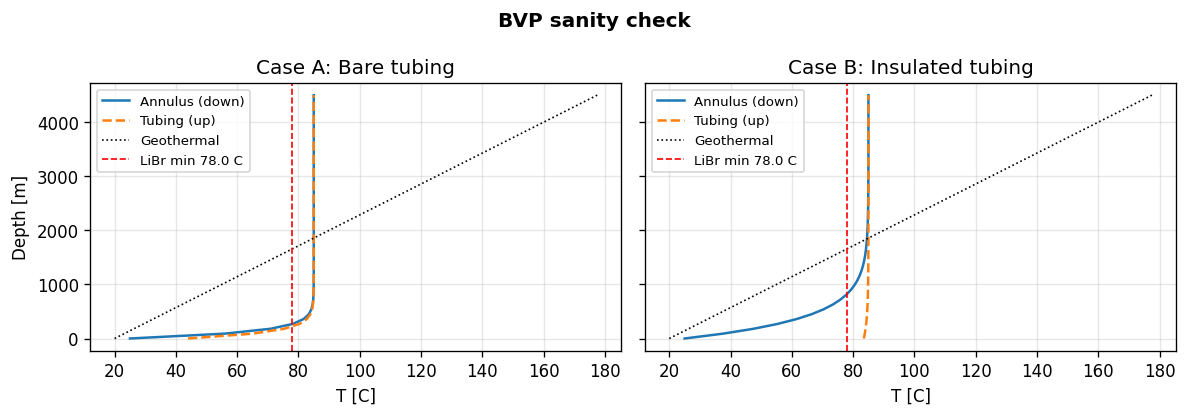

In [ ]:
def build_Phi_Psi(NTUeff_at, NTUa_bw, dz_star):
    A   = np.array([[-(NTUeff_at + NTUa_bw),  NTUeff_at],
                    [-NTUeff_at,                NTUeff_at]])
    Phi = expm(A * dz_star)
    Psi = np.linalg.solve(A, Phi - np.eye(2))
    return Phi, Psi


def solve_dbhe_bvp(NTUeff_at, NTUa_bw, theta_bw_cc, NZ_param, theta_a_in=0.):
    dz       = 1. / NZ_param
    Phi, Psi = build_Phi_Psi(NTUeff_at, NTUa_bw, dz)
    yH = np.zeros((NZ_param+1, 2));  yH[0] = [0., 1.]
    yP = np.zeros((NZ_param+1, 2));  yP[0] = [theta_a_in, 0.]
    for k in range(NZ_param):
        b_k     = np.array([NTUa_bw * theta_bw_cc[k], 0.])
        yH[k+1] = Phi @ yH[k]
        yP[k+1] = Phi @ yP[k] + Psi @ b_k
    s     = (yP[NZ_param,1] - yP[NZ_param,0]) / (yH[NZ_param,0] - yH[NZ_param,1])
    theta = s * yH + yP
    return theta[:,0], theta[:,1]


# ── Quick BVP sanity check ────────────────────────────────────────────────
theta_bw_test = 0.6 * np.ones(NZ)
dT_scale      = 100.
z_star        = np.linspace(0., 1., NZ+1)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for ax, lbl, kt in zip(axes,
        ['Case A: Bare tubing', 'Case B: Insulated tubing'],
        [kt_bare, kt_insulated]):
    at, bw, _, _, _ = compute_NTUs(flow_rate_m3_h_demo, Lbh_default, props_ref, kt)
    ta, ttb   = solve_dbhe_bvp(at, bw, theta_bw_test, NZ) # Pass NZ here for the sanity check
    ax.plot(ta*dT_scale + Tin,  z_star*Lbh_default, label='Annulus (down)')
    ax.plot(ttb*dT_scale + Tin, z_star*Lbh_default, label='Tubing (up)', ls='--')
    # Add geothermal temperature profile
    ax.plot(T_surf + Gg * z_star * Lbh_default, z_star * Lbh_default,
            color='k', ls=':', lw=1, label='Geothermal')
    ax.axvline(T_libr_min, color='r', ls='--', lw=1, label=f'LiBr min {T_libr_min} C')
    ax.set_xlabel('T [C]'); ax.set_title(lbl)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.invert_yaxis()
    Tret = Tin + ttb[0] * dT_scale
    status = 'Above LiBr threshold' if Tret >= T_libr_min else 'Below LiBr threshold'
    print(f"{lbl}: Tret = {Tret:.1f} C  ({status})")
axes[0].set_ylabel('Depth [m]')
plt.suptitle('BVP sanity check', fontweight='bold')
plt.tight_layout(); plt.show()

## Cell 8 · LiBr Chiller Model  *(auto-computed)*

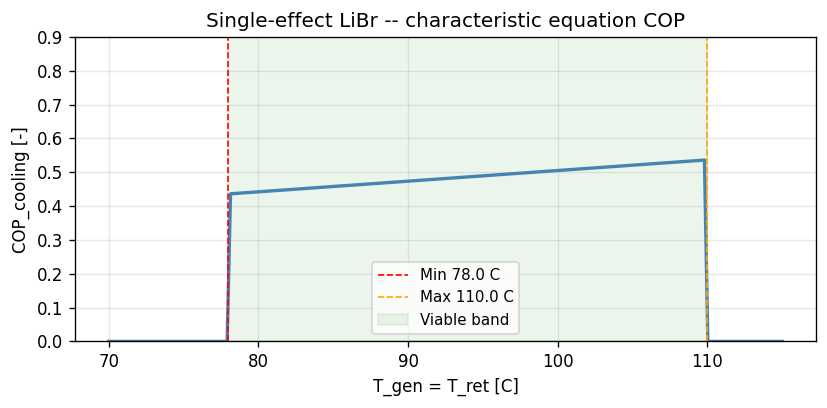

COP at key temperatures:
  T_ret = 78 C  -->  COP = 0.436
  T_ret = 85 C  -->  COP = 0.458
  T_ret = 95 C  -->  COP = 0.490
  T_ret = 105 C  -->  COP = 0.521
  T_ret = 110 C  -->  COP = 0.537


In [ ]:
def COP_LiBr(T_gen):
    if T_gen < T_libr_min or T_gen > T_libr_max:
        return 0.0
    ddt = T_gen + T_evap - f_char * (T_cond + T_abs)
    return max(0., a_char + b_char * ddt)


def cold_output(mdot, cp, T_ret):
    Q_geo  = mdot * cp * max(T_ret - Tin, 0.)
    cop    = COP_LiBr(T_ret)
    Q_cold = Q_geo * cop
    Q_cold_RT = Q_cold / 3517.0 # 1 RT = 3.517 kW = 3517 W
    return Q_cold, Q_geo, cop, Q_cold_RT


T_gen_arr = np.linspace(70., 115., 200)
COP_arr   = [COP_LiBr(T) for T in T_gen_arr]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(T_gen_arr, COP_arr, 'steelblue', lw=2)
ax.axvline(T_libr_min, color='r',      ls='--', lw=1, label=f'Min {T_libr_min} C')
ax.axvline(T_libr_max, color='orange', ls='--', lw=1, label=f'Max {T_libr_max} C')
ax.fill_betweenx([0., 0.9], T_libr_min, T_libr_max,
                 alpha=0.08, color='green', label='Viable band')
ax.set_xlabel('T_gen = T_ret [C]'); ax.set_ylabel('COP_cooling [-]')
ax.set_title('Single-effect LiBr -- characteristic equation COP')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(0., 0.9)
plt.tight_layout(); plt.show()

print("COP at key temperatures:")
for T in [T_libr_min, 85., 95., 105., T_libr_max]:
    print(f"  T_ret = {T:.0f} C  -->  COP = {COP_LiBr(T):.3f}")

## Cell 9 · Coupled DBHE-Chiller Solver  *(auto-computed)*

In [ ]:
def T_inf_z(z_arr):
    return T_surf + Gg * z_arr


def run_dbhe(Lbh, flow_rate_m3_h, kt, nz_param=NZ, neig_param=Neig, verbose=True):
    """Coupled BVP+GITT solver with time-stepped analytical tail correction.

    The GITT series is truncated at neig_param explicitly time-stepped modes.
    The remaining tail (modes neig_param+1 to infinity) is represented by a
    single lumped state variable U_tail that obeys the same GITT update rule:

        U_tail[k+1] = U_tail[k] * decay_tail
                    + R_tail * (1 - decay_tail) * q_eff[k]

    where
        R_tail    = R_ss - partial_sum(neig_param)  [K.m/W, exact via SS identity]
        decay_tail = exp(-alpha_e * beta_{N+1}^2 * dt)
        beta_{N+1} ~ beta_N + pi/Rfar  (next eigenvalue estimate)

    This makes the coupled output independent of neig_param once all
    dynamically significant modes (tau_n > dt) are explicitly retained.
    """
    label  = 'Bare' if kt > 1. else 'Insulated'
    T_mean = min((Tin + T_surf + Gg * Lbh * 0.6) / 2., 95.)
    pr     = water_props(T_mean)
    NTUat, NTUbw, mdot, va_annulus, v_tubing = compute_NTUs(flow_rate_m3_h, Lbh, pr, kt)

    # ── GITT Set A arrays ──────────────────────────────────────────────────
    (betas_arr_local, norms_arr_local, psi_rce_local, inv_wts_local,
     forc_coeff_local, tau_arr_local, decay_step_local) = _get_gitt_arrays(
        neig_param, rce, Rfar, ke, alpha_e, dt_step)

    # ── Tail correction parameters ─────────────────────────────────────────
    R_ss_val   = np.log(Rfar / rce) / (2. * np.pi * ke)
    partial    = np.sum(psi_rce_local**2 / (betas_arr_local**2 * norms_arr_local)) \
                 / (2. * np.pi * ke)
    R_tail     = R_ss_val - partial          # exact missing amplitude [K.m/W]
    beta_next  = betas_arr_local[-1] + np.pi / Rfar   # next eigenvalue estimate
    decay_tail = np.exp(-alpha_e * beta_next**2 * dt_step)

    if verbose:
        print(f"[{label}] Lbh={Lbh:.0f}m  Flow={flow_rate_m3_h:.1f}m3/h  "
              f"mdot={mdot:.3f}kg/s  va={va_annulus:.3f}m/s  vtb={v_tubing:.3f}m/s  "
              f"NTUat={NTUat:.3f}  NTUbw={NTUbw:.3f}")
        print(f"  Tail: R_ss={R_ss_val:.5f}  partial={partial:.5f}  "
              f"R_tail={R_tail:.5f} K.m/W  "
              f"({100.*R_tail/R_ss_val:.1f}% of R_ss)  "
              f"decay_tail/step={decay_tail:.5f}")

    dz_m   = Lbh / nz_param
    z_cc   = (np.arange(nz_param) + 0.5) * dz_m
    U_bar  = np.zeros((nz_param, neig_param))   # Set A GITT state
    U_tail = np.zeros(nz_param)                 # lumped tail state [K]
    Tbw    = T_inf_z(z_cc).copy()
    dT_sc  = max(Tbw.max() - Tin, 1.)

    # G_eff_ace [W/(m.K)]: annulus-to-borehole-wall conductance per unit length
    G_eff_ace = NTUbw * mdot * pr['cp'] / Lbh

    def _gitt_step(U_bar, U_tail, T_a_cc):
        q_bw  = G_eff_ace * (T_a_cc - Tbw)
        q_eff = q_bw * f_op
        # Set A update
        U_bar = (U_bar * decay_step_local[np.newaxis, :]
                 + forc_coeff_local[np.newaxis, :] * (1. - decay_step_local[np.newaxis, :])
                 * q_eff[:, np.newaxis])
        # Tail update: same GITT rule with scalar forcing coefficient R_tail
        U_tail = U_tail * decay_tail + R_tail * (1. - decay_tail) * q_eff
        T_bw_out = T_inf_z(z_cc) \
                   + (U_bar * inv_wts_local[np.newaxis, :]).sum(axis=1) \
                   + U_tail
        return U_bar, U_tail, T_bw_out

    def _cc(th): return 0.5 * (th[:-1] + th[1:])

    Tret_h     = np.zeros(n_steps)
    Qgeo_h     = np.zeros(n_steps)
    Qcold_h    = np.zeros(n_steps)
    COP_h      = np.zeros(n_steps)
    Qcold_RT_h = np.zeros(n_steps)
    viable     = np.zeros(n_steps, dtype=bool)

    steps_per_year = 365.25 / n_days_per_step
    print_interval = max(1, int(steps_per_year)) if steps_per_year >= 1 else n_steps

    for mo in range(n_steps):
        theta_bw            = (Tbw - Tin) / dT_sc
        ta, ttb             = solve_dbhe_bvp(NTUat, NTUbw, theta_bw, nz_param)
        T_a_cc              = Tin + _cc(ta) * dT_sc
        T_ret               = Tin + ttb[0]  * dT_sc
        U_bar, U_tail, Tbw  = _gitt_step(U_bar, U_tail, T_a_cc)
        dT_sc               = max(Tbw.max() - Tin, 1.)

        Q_cold, Q_geo, cop, Q_cold_RT = cold_output(mdot, pr['cp'], T_ret)
        Tret_h[mo]     = T_ret
        Qgeo_h[mo]     = Q_geo
        Qcold_h[mo]    = Q_cold
        COP_h[mo]      = cop
        Qcold_RT_h[mo] = Q_cold_RT
        viable[mo]     = T_ret >= T_libr_min

        if verbose and (mo % print_interval == 0 or mo == n_steps - 1):
            yr     = (mo + 1) * n_days_per_step / 365.25
            status = 'OK' if T_ret >= T_libr_min else 'END-OF-LIFE'
            print(f"  Year {yr:5.1f}: Tret={T_ret:.1f} C  "
                  f"Q_geo={Q_geo/1e3:.1f} kW  "
                  f"Q_cold={Q_cold/1e3:.1f} kW  "
                  f"COP={cop:.3f}  [{status}]")

    eol_steps  = int(np.argmax(~viable)) if not viable.all() else n_steps
    eol_years  = eol_steps * n_days_per_step / 365.25
    total_GWh  = float(Qcold_h.sum()) * dt_step * f_op / 3.6e9

    ta_profile_final  = Tin + ta  * dT_sc
    ttb_profile_final = Tin + ttb * dT_sc

    return dict(
        Tret=Tret_h, Qgeo=Qgeo_h, Qcold=Qcold_h, COP=COP_h,
        viable=viable, eol_years=eol_years, label=label,
        Lbh=Lbh, flow_rate_m3_h=flow_rate_m3_h, kt=kt, mdot=mdot,
        va_annulus=va_annulus, v_tubing=v_tubing,
        NTUat=NTUat, NTUbw=NTUbw,
        total_cold_GWh=total_GWh,
        Qcold_RT=Qcold_RT_h,
        ta_profile=ta_profile_final,
        ttb_profile=ttb_profile_final,
        R_tail=float(R_tail), R_ss=float(R_ss_val),
    )


## Cell 10 · Demo Run

In [ ]:
print("=" * 60)
print("Case A: Bare steel tubing")
print("=" * 60)
res_bare = run_dbhe(Lbh=Lbh_default, flow_rate_m3_h=flow_rate_m3_h_demo, kt=kt_bare, verbose=True)

print()
print("=" * 60)
print("Case B: Insulated (VIT) tubing")
print("=" * 60)
res_ins = run_dbhe(Lbh=Lbh_default, flow_rate_m3_h=flow_rate_m3_h_demo, kt=kt_insulated, verbose=True)

Case A: Bare steel tubing
[Bare] Lbh=4500m  Flow=10.0m3/h  mdot=2.714kg/s  va=0.176m/s  vtb=0.921m/s  NTUat=78.371  NTUbw=11.467
  Tail: R_ss=0.54434  partial=0.36966  R_tail=0.17468 K.m/W  (32.1% of R_ss)  decay_tail/step=0.97956
  Year   0.0: Tret=25.5 C  Q_geo=5.3 kW  Q_cold=0.0 kW  COP=0.000  [END-OF-LIFE]
  Year   1.0: Tret=26.3 C  Q_geo=15.2 kW  Q_cold=0.0 kW  COP=0.000  [END-OF-LIFE]
  Year   2.0: Tret=26.4 C  Q_geo=15.4 kW  Q_cold=0.0 kW  COP=0.000  [END-OF-LIFE]
  Year   3.0: Tret=26.4 C  Q_geo=15.5 kW  Q_cold=0.0 kW  COP=0.000  [END-OF-LIFE]
  Year   4.0: Tret=26.4 C  Q_geo=15.6 kW  Q_cold=0.0 kW  COP=0.000  [END-OF-LIFE]
  Year   5.0: Tret=26.4 C  Q_geo=15.6 kW  Q_cold=0.0 kW  COP=0.000  [END-OF-LIFE]
  Year   6.0: Tret=26.4 C  Q_geo=15.7 kW  Q_cold=0.0 kW  COP=0.000  [END-OF-LIFE]
  Year   7.0: Tret=26.4 C  Q_geo=15.7 kW  Q_cold=0.0 kW  COP=0.000  [END-OF-LIFE]
  Year   8.0: Tret=26.4 C  Q_geo=15.7 kW  Q_cold=0.0 kW  COP=0.000  [END-OF-LIFE]
  Year   9.0: Tret=26.4 C  Q_geo

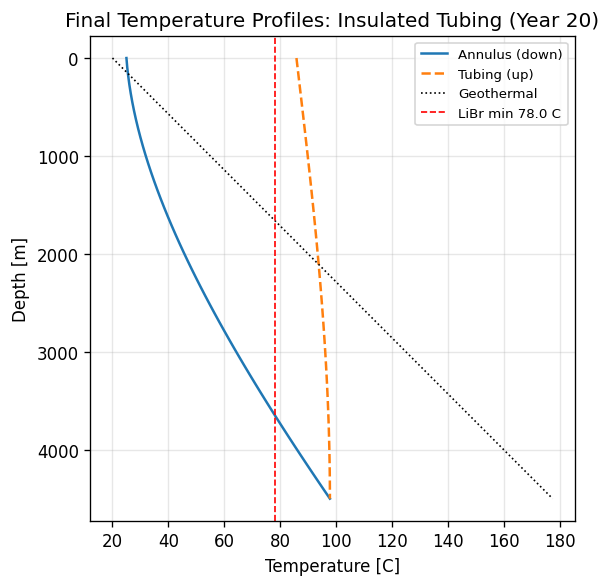

In [ ]:
# Plot final temperature profiles for the Insulated (VIT) case
fig, ax = plt.subplots(figsize=(5, 5))

# Geothermal depth array
z_plot = np.linspace(0., res_ins['Lbh'], NZ+1)

# Plot annulus and tubing profiles
ax.plot(res_ins['ta_profile'], z_plot, label='Annulus (down)')
ax.plot(res_ins['ttb_profile'], z_plot, label='Tubing (up)', ls='--')

# Plot geothermal temperature profile
ax.plot(T_surf + Gg * z_plot, z_plot, color='k', ls=':', lw=1, label='Geothermal')

# Add LiBr min threshold
ax.axvline(T_libr_min, color='r', ls='--', lw=1, label=f'LiBr min {T_libr_min} C')

ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Depth [m]')
ax.set_title(f'Final Temperature Profiles: Insulated Tubing (Year {n_years})')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Cell 11 · Convergence Study — Axial Grid (NZ)
For each value of NZ, run the full 20-year coupled solver with
baseline Neig and dt. Report T_ret and Q_cold at years 1, 5, 10, 20.
Convergence is declared when the result shifts < 0.1 K between successive grids.


Running NZ convergence sweep...
  Baseline Neig=60, dt=0.25 days
  NZ=  10 ... Tret yr20=81.79 C  Qcold yr20=289.27 kW
  NZ=  20 ... Tret yr20=84.89 C  Qcold yr20=311.70 kW
  NZ=  30 ... Tret yr20=85.51 C  Qcold yr20=316.27 kW
  NZ=  50 ... Tret yr20=85.84 C  Qcold yr20=318.67 kW
  NZ=  80 ... Tret yr20=85.95 C  Qcold yr20=319.50 kW
  NZ= 120 ... Tret yr20=85.99 C  Qcold yr20=319.80 kW

    NZ  Tret_yr01  Tret_yr05  Tret_yr10  Tret_yr20  Qcold_yr01  Qcold_yr05  Qcold_yr10  Qcold_yr20
--------------------------------------------------------------------------------------------------
    10        90.89        85.70        83.68        81.79       357.039       317.619       302.861       289.266
    20        94.04        88.83        86.80        84.89       381.909       341.204       325.870       311.697
    30        94.66        89.46        87.43        85.51       386.926       345.992       330.552       316.272
    50        94.99        89.78        87.75        85.84       38

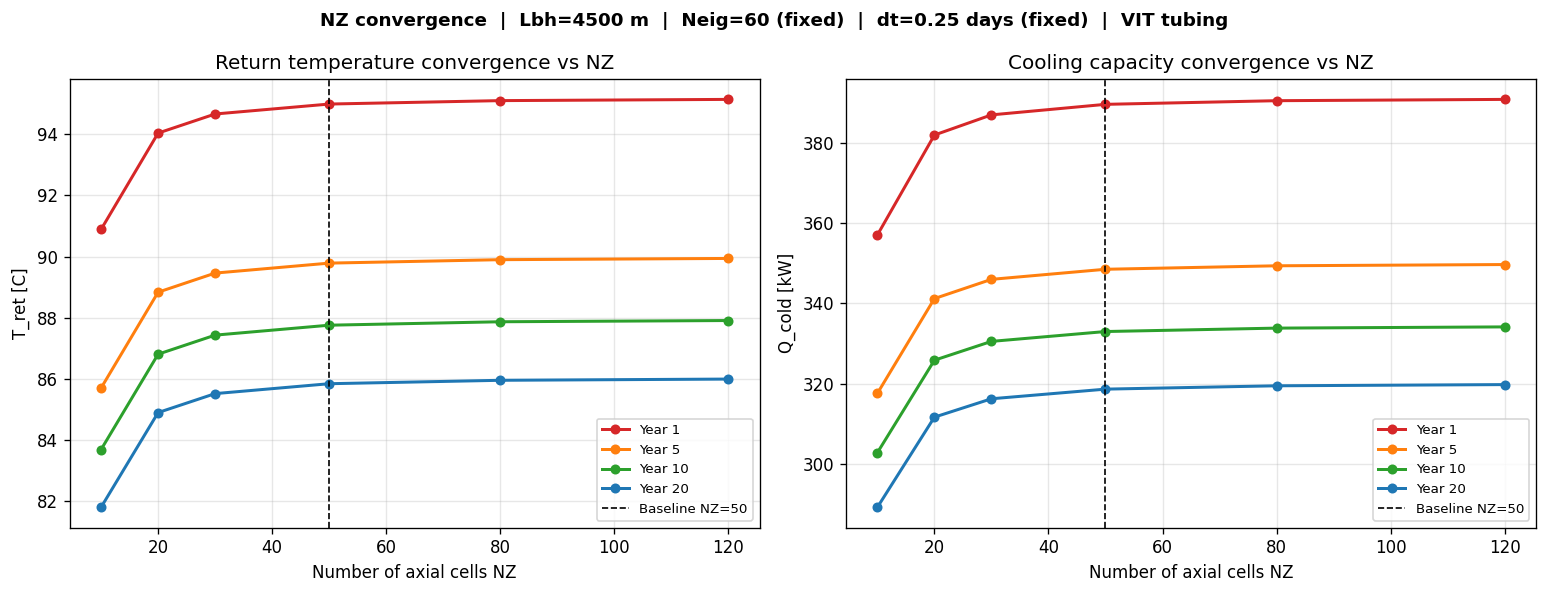


T_ret yr-20 change between successive NZ values (baseline is the finest):
  NZ   10 ->   20:  delta=3.099 K
  NZ   20 ->   30:  delta=0.621 K
  NZ   30 ->   50:  delta=0.324 K
  NZ   50 ->   80:  delta=0.112 K
  NZ   80 ->  120:  delta=0.040 K  <<< CONVERGED (<0.1 K)


In [ ]:
# ── NZ convergence — insulated tubing, Lbh_default, flow_rate_m3_h_demo ──
print('Running NZ convergence sweep...')
print(f'  Baseline Neig={Neig}, dt={n_days_per_step} days')

_conv_years = [1, 5, 10, 20]

def _pick_years(arr, years, n_dps=n_days_per_step):
    """Extract T_ret (or Qcold) at specific year indices."""
    steps_per_yr = 365.25 / n_dps
    idxs = [min(int(y * steps_per_yr) - 1, len(arr)-1) for y in years]
    return np.array([arr[i] for i in idxs])

nz_Tret  = {}   # nz -> array[years]
nz_Qcold = {}

for nz_val in NZ_sweep:
    print(f'  NZ={nz_val:4d} ...', end=' ', flush=True)
    r = run_dbhe(Lbh_default, flow_rate_m3_h_demo, kt_demo,
                 nz_param=nz_val, neig_param=Neig, verbose=False)
    nz_Tret[nz_val]  = _pick_years(r['Tret'],  _conv_years)
    nz_Qcold[nz_val] = _pick_years(r['Qcold'], _conv_years) / 1e3
    print(f'Tret yr20={r["Tret"][-1]:.2f} C  Qcold yr20={r["Qcold"][-1]/1e3:.2f} kW')

# ── Table ─────────────────────────────────────────────────────────────────
print()
hdr = f"{'NZ':>6}" + ''.join([f"  Tret_yr{y:02d}" for y in _conv_years])
hdr += ''.join([f"  Qcold_yr{y:02d}" for y in _conv_years])
print(hdr); print('-' * len(hdr))
for nz_val in NZ_sweep:
    row = f"{nz_val:>6}"
    row += ''.join([f"  {nz_Tret[nz_val][i]:>11.2f}" for i in range(len(_conv_years))])
    row += ''.join([f"  {nz_Qcold[nz_val][i]:>12.3f}" for i in range(len(_conv_years))])
    print(row)

# ── Plot ──────────────────────────────────────────────────────────────────
NZ_arr = np.array(NZ_sweep)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_yr = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
for ax, data_dict, ylabel, title in zip(
        axes,
        [nz_Tret, nz_Qcold],
        ['T_ret [C]', 'Q_cold [kW]'],
        ['Return temperature convergence vs NZ',
         'Cooling capacity convergence vs NZ']):
    mat = np.array([data_dict[nz_val] for nz_val in NZ_sweep])
    for j, (yr, col) in enumerate(zip(_conv_years, colors_yr)):
        ax.plot(NZ_arr, mat[:, j], '-o', color=col, lw=1.8, ms=5,
                label=f'Year {yr}')
    # Mark baseline NZ
    ax.axvline(NZ, color='k', ls='--', lw=1, label=f'Baseline NZ={NZ}')
    ax.set_xlabel('Number of axial cells NZ')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f'NZ convergence  |  Lbh={Lbh_default:.0f} m  |  '
    f'Neig={Neig} (fixed)  |  dt={n_days_per_step} days (fixed)  |  '
    f'VIT tubing',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('convergence_NZ.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Convergence metric: delta between successive NZ values ────────────────
print()
print('T_ret yr-20 change between successive NZ values (baseline is the finest):')
Tret20_arr = np.array([nz_Tret[nz_val][-1] for nz_val in NZ_sweep])
for i in range(1, len(NZ_sweep)):
    delta = abs(Tret20_arr[i] - Tret20_arr[i-1])
    flag  = '  <<< CONVERGED (<0.1 K)' if delta < 0.1 else ''
    print(f'  NZ {NZ_sweep[i-1]:>4d} -> {NZ_sweep[i]:>4d}:  delta={delta:.3f} K{flag}')


## Cell 12 · Convergence Study — GITT Eigenvalues (N_eig)

Tests how many explicitly time-stepped GITT modes are needed for the
**coupled** BVP+GITT solver to produce a converged return temperature
and cooling capacity. The analytical tail correction is active in
`run_dbhe` for all runs, so the result reflects genuine dynamic-mode
convergence: once all modes with `tau_n > dt` are retained, adding more
modes changes nothing because the tail already accounts for their
collective contribution exactly.

A second panel shows the eigenvalue decay-time spectrum, providing the
physical justification for the chosen baseline N_eig.


Running N_eig convergence sweep (tail correction active in run_dbhe)...
  Baseline NZ=50, dt=0.25 days, Lbh=4500 m, VIT tubing
  Neig=  10 ... Tret yr1=104.108 C  yr20=85.749 C  R_tail=0.30157 K.m/W  (55.4% of R_ss)
  Neig=  20 ... Tret yr1=94.460 C  yr20=85.820 C  R_tail=0.25247 K.m/W  (46.4% of R_ss)
  Neig=  40 ... Tret yr1=94.913 C  yr20=85.835 C  R_tail=0.20323 K.m/W  (37.3% of R_ss)
  Neig=  60 ... Tret yr1=94.989 C  yr20=85.838 C  R_tail=0.17468 K.m/W  (32.1% of R_ss)
  Neig= 100 ... Tret yr1=95.021 C  yr20=85.839 C  R_tail=0.13952 K.m/W  (25.6% of R_ss)
  Neig= 200 ... Tret yr1=95.031 C  yr20=85.839 C  R_tail=0.09508 K.m/W  (17.5% of R_ss)

  Neig  Tret_yr01  Tret_yr05  Tret_yr10  Tret_yr20  Qcold_yr01  Qcold_yr05  Qcold_yr10  Qcold_yr20
--------------------------------------------------------------------------------------------------
    10      104.108       89.321       87.552       85.749       466.143       344.937       331.486       318.010
    20       94.460       89.6

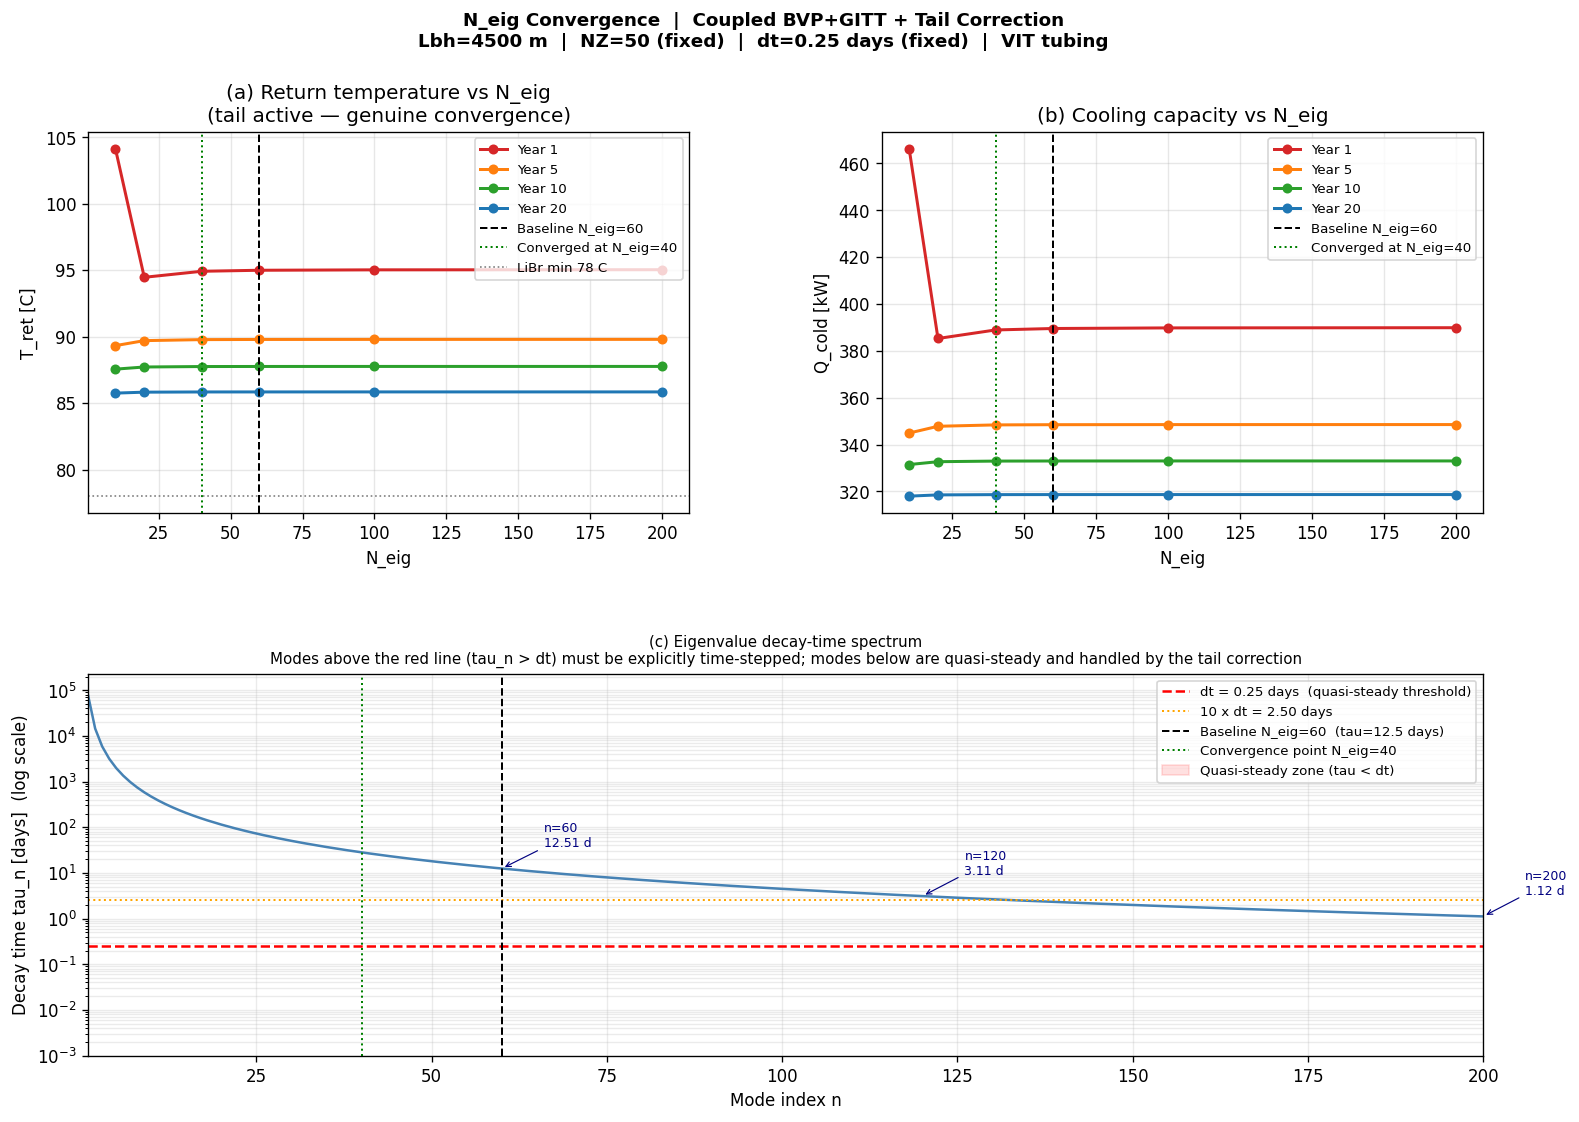

Figure saved: convergence_Neig.png


In [ ]:
# ── Cell 12: N_eig convergence — coupled solver with tail correction ──────
# run_dbhe now carries the time-stepped tail correction, so all runs below
# are self-consistent regardless of N_eig. Convergence here is genuine.

if USE_QS_CORRECTION:
    raise RuntimeError(
        'USE_QS_CORRECTION must be False. Set it in Cell 2 and re-run.')

print('Running N_eig convergence sweep (tail correction active in run_dbhe)...')
print(f'  Baseline NZ={NZ}, dt={n_days_per_step} days, '
      f'Lbh={Lbh_default:.0f} m, VIT tubing')

neig_Tret  = {}
neig_Qcold = {}

for neig_val in Neig_sweep:
    print(f'  Neig={neig_val:4d} ...', end=' ', flush=True)
    r = run_dbhe(Lbh_default, flow_rate_m3_h_demo, kt_demo,
                 nz_param=NZ, neig_param=neig_val, verbose=False)
    neig_Tret[neig_val]  = _pick_years(r['Tret'],  _conv_years)
    neig_Qcold[neig_val] = _pick_years(r['Qcold'], _conv_years) / 1e3
    print(f'Tret yr1={neig_Tret[neig_val][0]:.3f} C  '
          f'yr20={neig_Tret[neig_val][-1]:.3f} C  '
          f'R_tail={r["R_tail"]:.5f} K.m/W  '
          f'({100.*r["R_tail"]/r["R_ss"]:.1f}% of R_ss)')

# ── Convergence table ──────────────────────────────────────────────────────
print()
hdr = f"{'Neig':>6}" + ''.join([f"  Tret_yr{y:02d}" for y in _conv_years])
hdr += ''.join([f"  Qcold_yr{y:02d}" for y in _conv_years])
print(hdr); print('-' * len(hdr))
for neig_val in Neig_sweep:
    row = f"{neig_val:>6}"
    row += ''.join([f"  {neig_Tret[neig_val][i]:>11.3f}" for i in range(len(_conv_years))])
    row += ''.join([f"  {neig_Qcold[neig_val][i]:>12.3f}" for i in range(len(_conv_years))])
    print(row)

# ── Convergence deltas ─────────────────────────────────────────────────────
print()
print('T_ret yr-20 change between successive N_eig values:')
Tret20_neig = np.array([neig_Tret[n][-1] for n in Neig_sweep])
first_converged = None
for i in range(1, len(Neig_sweep)):
    delta = abs(Tret20_neig[i] - Tret20_neig[i-1])
    flag  = ''
    if delta < 0.05 and first_converged is None:
        flag = '  <<< CONVERGED (<0.05 K)'
        first_converged = Neig_sweep[i]
    print(f'  Neig {Neig_sweep[i-1]:>4d} -> {Neig_sweep[i]:>4d}:  '
          f'delta={delta:.4f} K{flag}')
if first_converged:
    print(f'\n  --> Coupled solver converges at N_eig = {first_converged}')

# ── Eigenvalue decay-time spectrum ─────────────────────────────────────────
print()
print('Computing eigenvalue spectrum...')
N_spec = max(Neig_sweep)
(betas_spec, _, _, _, _, tau_spec, decay_spec) = \
    _get_gitt_arrays(N_spec, rce, Rfar, ke, alpha_e, dt_step)
tau_spec_days = tau_spec / t_day
# searchsorted on the negated array finds the first mode where tau < dt.
# Clip to N_spec-1 in case all retained modes have tau > dt.
idx_dt = min(int(np.searchsorted(-tau_spec_days, -n_days_per_step)), N_spec - 1)
print(f'  First mode with tau < dt ({n_days_per_step} days): '
      f'mode {idx_dt+1} (tau={tau_spec_days[idx_dt]:.3f} days)')
print(f'  Baseline N_eig={Neig}: '
      f'tau={tau_spec_days[Neig-1]:.2f} days  '
      f'decay/step={decay_spec[Neig-1]:.5f}')

# ── Figure ─────────────────────────────────────────────────────────────────
Neig_arr = np.array(Neig_sweep)
fig = plt.figure(figsize=(15, 10))
gs  = plt.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# (a) T_ret
ax_a = fig.add_subplot(gs[0, 0])
mat_T = np.array([neig_Tret[n] for n in Neig_sweep])
for j, (yr, col) in enumerate(zip(_conv_years, colors_yr)):
    ax_a.plot(Neig_arr, mat_T[:, j], '-o', color=col, lw=1.8, ms=5, label=f'Year {yr}')
ax_a.axvline(Neig, color='k', ls='--', lw=1.2, label=f'Baseline N_eig={Neig}')
if first_converged:
    ax_a.axvline(first_converged, color='green', ls=':', lw=1.2,
                 label=f'Converged at N_eig={first_converged}')
ax_a.axhline(T_libr_min, color='gray', ls=':', lw=1., label=f'LiBr min {T_libr_min:.0f} C')
ax_a.set_xlabel('N_eig'); ax_a.set_ylabel('T_ret [C]')
ax_a.set_title('(a) Return temperature vs N_eig\n(tail active — genuine convergence)')
ax_a.legend(fontsize=8); ax_a.grid(True, alpha=0.3)

# (b) Q_cold
ax_b = fig.add_subplot(gs[0, 1])
mat_Q = np.array([neig_Qcold[n] for n in Neig_sweep])
for j, (yr, col) in enumerate(zip(_conv_years, colors_yr)):
    ax_b.plot(Neig_arr, mat_Q[:, j], '-o', color=col, lw=1.8, ms=5, label=f'Year {yr}')
ax_b.axvline(Neig, color='k', ls='--', lw=1.2, label=f'Baseline N_eig={Neig}')
if first_converged:
    ax_b.axvline(first_converged, color='green', ls=':', lw=1.2,
                 label=f'Converged at N_eig={first_converged}')
ax_b.set_xlabel('N_eig'); ax_b.set_ylabel('Q_cold [kW]')
ax_b.set_title('(b) Cooling capacity vs N_eig')
ax_b.legend(fontsize=8); ax_b.grid(True, alpha=0.3)

# (c) Decay-time spectrum — full bottom row
ax_c = fig.add_subplot(gs[1, :])
mode_idx = np.arange(1, N_spec + 1)
ax_c.semilogy(mode_idx, tau_spec_days, color='steelblue', lw=1.5)
ax_c.axhline(n_days_per_step, color='red', ls='--', lw=1.5,
             label=f'dt = {n_days_per_step} days  (quasi-steady threshold)')
ax_c.axhline(10. * n_days_per_step, color='orange', ls=':', lw=1.2,
             label=f'10 x dt = {10.*n_days_per_step:.2f} days')
ax_c.axvline(Neig, color='k', ls='--', lw=1.2,
             label=f'Baseline N_eig={Neig}  (tau={tau_spec_days[Neig-1]:.1f} days)')
if first_converged and first_converged <= N_spec:
    ax_c.axvline(first_converged, color='green', ls=':', lw=1.2,
                 label=f'Convergence point N_eig={first_converged}')
ax_c.fill_between(mode_idx, 1e-6, n_days_per_step,
                  where=tau_spec_days < n_days_per_step,
                  alpha=0.12, color='red', label='Quasi-steady zone (tau < dt)')
for n_ann in [Neig, min(Neig * 2, N_spec), N_spec]:
    ax_c.annotate(
        f'n={n_ann}\n{tau_spec_days[n_ann-1]:.2f} d',
        xy=(n_ann, tau_spec_days[n_ann-1]),
        xytext=(n_ann + max(2, int(N_spec * 0.03)),
                tau_spec_days[n_ann-1] * 3.),
        fontsize=7.5, color='navy',
        arrowprops=dict(arrowstyle='->', color='navy', lw=0.7))
ax_c.set_xlabel('Mode index n', fontsize=10)
ax_c.set_ylabel('Decay time tau_n [days]  (log scale)', fontsize=10)
ax_c.set_title(
    '(c) Eigenvalue decay-time spectrum\n'
    'Modes above the red line (tau_n > dt) must be explicitly time-stepped; '
    'modes below are quasi-steady and handled by the tail correction',
    fontsize=9)
ax_c.set_xlim(1, N_spec); ax_c.set_ylim(1e-3, tau_spec_days[0] * 3.)
ax_c.legend(fontsize=8, loc='upper right')
ax_c.grid(True, which='both', alpha=0.25)

plt.suptitle(
    f'N_eig Convergence  |  Coupled BVP+GITT + Tail Correction\n'
    f'Lbh={Lbh_default:.0f} m  |  NZ={NZ} (fixed)  |  '
    f'dt={n_days_per_step} days (fixed)  |  VIT tubing',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('convergence_Neig.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: convergence_Neig.png')


## Cell 13 · Convergence Study — Time Step (dt)
For each time step, run the full simulation with baseline NZ and Neig.
The GITT update is exact for a piecewise-constant forcing within each step;
temporal error arises only from the BVP coupling (iterative within the step).
Convergence is expected when T_ret shift between successive dt values is < 0.1 K.


Running dt convergence sweep...
  Baseline NZ=50, Neig=60
  dt=3.0000 days ... Tret yr20=85.838 C  Qcold yr20=318.674 kW
  dt=1.0000 days ... Tret yr20=85.838 C  Qcold yr20=318.671 kW
  dt=0.2500 days ... Tret yr20=85.838 C  Qcold yr20=318.670 kW
  dt=0.1250 days ... Tret yr20=85.838 C  Qcold yr20=318.670 kW
  dt=0.0625 days ... Tret yr20=85.838 C  Qcold yr20=318.670 kW
  Globals restored: dt_step=21600 s  n_steps=29220

  dt[days]  Tret_yr01  Tret_yr05  Tret_yr10  Tret_yr20  Qcold_yr01  Qcold_yr05  Qcold_yr10  Qcold_yr20
------------------------------------------------------------------------------------------------------
    3.0000       95.025       89.790       87.755       85.838       389.839       348.546       333.022       318.674
    1.0000       94.996       89.785       87.754       85.838       389.600       348.507       333.010       318.671
    0.2500       94.989       89.784       87.753       85.838       389.548       348.499       333.005       318.670
    0.1250  

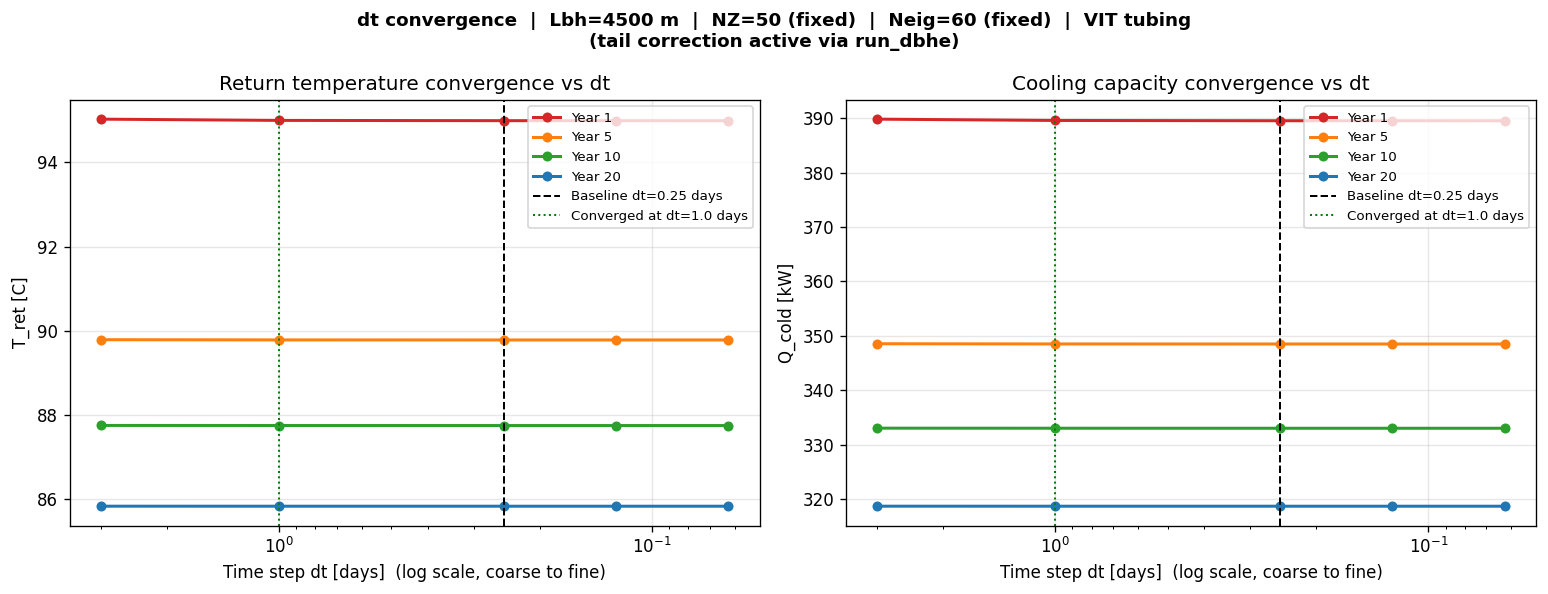

Figure saved: convergence_dt.png


In [ ]:
# ── Cell 13: dt convergence — uses run_dbhe directly ─────────────────────
# run_dbhe reads dt_step and n_steps from the global scope.
# We temporarily patch both globals for each dt value, call run_dbhe,
# then restore them. This ensures the tail correction and all other solver
# logic are identical to the production code — no custom loop needed.

print('Running dt convergence sweep...')
print(f'  Baseline NZ={NZ}, Neig={Neig}')

dt_Tret  = {}
dt_Qcold = {}

# Save baseline globals
_dt_step_baseline = dt_step
_n_steps_baseline = n_steps

for dt_val in dt_sweep:
    print(f'  dt={dt_val:.4f} days ...', end=' ', flush=True)

    # Patch globals that run_dbhe reads
    dt_step = dt_val * t_day
    n_steps = int(n_years * 365.25 / dt_val)

    r = run_dbhe(Lbh_default, flow_rate_m3_h_demo, kt_demo,
                 nz_param=NZ, neig_param=Neig, verbose=False)

    dt_Tret[dt_val]  = _pick_years(r['Tret'],  _conv_years, n_dps=dt_val)
    dt_Qcold[dt_val] = _pick_years(r['Qcold'], _conv_years, n_dps=dt_val) / 1e3
    print(f'Tret yr20={r["Tret"][-1]:.3f} C  '
          f'Qcold yr20={r["Qcold"][-1]/1e3:.3f} kW')

# Restore baseline globals
dt_step = _dt_step_baseline
n_steps = _n_steps_baseline
print(f'  Globals restored: dt_step={dt_step:.0f} s  n_steps={n_steps}')

# ── Table ──────────────────────────────────────────────────────────────────
print()
hdr = f"{'dt[days]':>10}" + ''.join([f"  Tret_yr{y:02d}" for y in _conv_years])
hdr += ''.join([f"  Qcold_yr{y:02d}" for y in _conv_years])
print(hdr); print('-' * len(hdr))
for dt_val in dt_sweep:
    row = f"{dt_val:>10.4f}"
    row += ''.join([f"  {dt_Tret[dt_val][i]:>11.3f}" for i in range(len(_conv_years))])
    row += ''.join([f"  {dt_Qcold[dt_val][i]:>12.3f}" for i in range(len(_conv_years))])
    print(row)

# ── Convergence metric ─────────────────────────────────────────────────────
print()
print('T_ret yr-20 change between successive dt values (coarse to fine):')
Tret20_dt = np.array([dt_Tret[dt_val][-1] for dt_val in dt_sweep])
first_converged_dt = None
for i in range(1, len(dt_sweep)):
    delta = abs(Tret20_dt[i] - Tret20_dt[i-1])
    flag  = ''
    if delta < 0.1 and first_converged_dt is None:
        flag = '  <<< CONVERGED (<0.1 K)'
        first_converged_dt = dt_sweep[i]
    print(f'  dt {dt_sweep[i-1]:.4f} -> {dt_sweep[i]:.4f} days:  '
          f'delta={delta:.4f} K{flag}')
if first_converged_dt:
    print(f'\n  --> dt convergence achieved at dt = {first_converged_dt} days')

# ── Plot ───────────────────────────────────────────────────────────────────
dt_arr = np.array(dt_sweep)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data_dict, ylabel, title in zip(
        axes,
        [dt_Tret, dt_Qcold],
        ['T_ret [C]', 'Q_cold [kW]'],
        ['Return temperature convergence vs dt',
         'Cooling capacity convergence vs dt']):
    mat = np.array([data_dict[dt_val] for dt_val in dt_sweep])
    for j, (yr, col) in enumerate(zip(_conv_years, colors_yr)):
        ax.semilogx(dt_arr, mat[:, j], '-o', color=col, lw=1.8, ms=5,
                    label=f'Year {yr}')
    ax.axvline(n_days_per_step, color='k', ls='--', lw=1.2,
               label=f'Baseline dt={n_days_per_step} days')
    if first_converged_dt:
        ax.axvline(first_converged_dt, color='green', ls=':', lw=1.2,
                   label=f'Converged at dt={first_converged_dt} days')
    ax.set_xlabel('Time step dt [days]  (log scale, coarse to fine)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.invert_xaxis()
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f'dt convergence  |  Lbh={Lbh_default:.0f} m  |  '
    f'NZ={NZ} (fixed)  |  Neig={Neig} (fixed)  |  VIT tubing\n'
    f'(tail correction active via run_dbhe)',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('convergence_dt.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: convergence_dt.png')


## Cell 14 · Convergence Summary — Three-Parameter Panel
Single figure combining yr-20 T_ret sensitivity to all three parameters
on a common Δ-T axis, with the chosen baseline value highlighted.
This is the justification figure for use in publications.


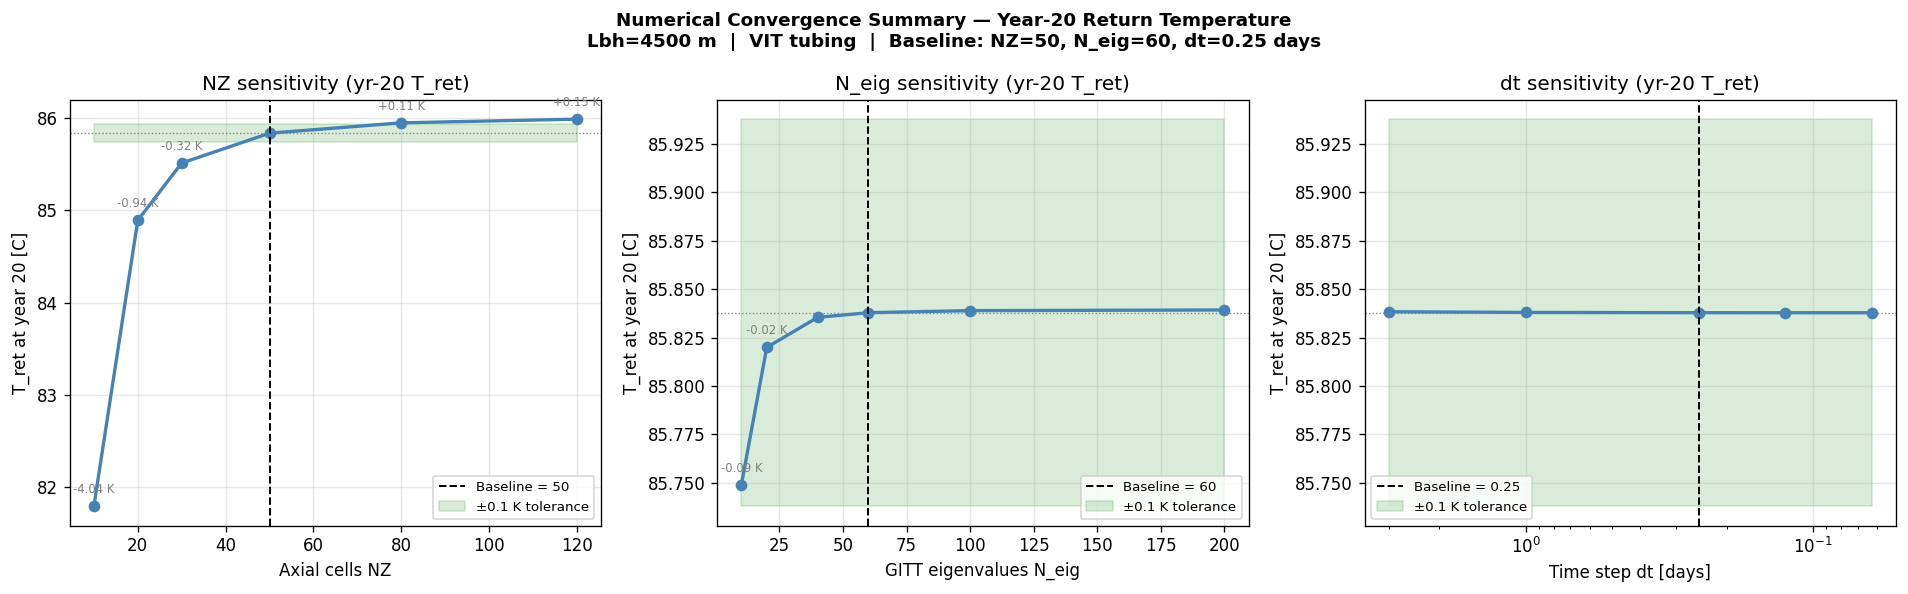


Convergence figures saved: convergence_NZ.png, convergence_Neig.png, convergence_dt.png, convergence_summary.png


In [ ]:
# ── Combined convergence summary panel ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def _summary_ax(ax, x_vals, data_dict, baseline_val, xlabel, title,
                logx=False):
    """Plot yr-20 T_ret vs parameter with ±0.1 K tolerance band."""
    x_arr = np.array(x_vals)
    Tret20 = np.array([data_dict[v][-1] for v in x_vals])
    ref    = data_dict[baseline_val][-1]   # baseline value
    delta  = Tret20 - ref

    plot_fn = ax.semilogx if logx else ax.plot
    plot_fn(x_arr, Tret20, '-o', color='steelblue', lw=2, ms=6)
    ax.axvline(baseline_val, color='k', ls='--', lw=1.2,
               label=f'Baseline = {baseline_val}')
    ax.axhline(ref, color='gray', ls=':', lw=0.8)
    ax.fill_between(x_arr, ref - 0.1, ref + 0.1,
                    alpha=0.15, color='green', label='±0.1 K tolerance')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('T_ret at year 20 [C]')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Annotate deltas
    for xi, Ti, di in zip(x_arr, Tret20, delta):
        if abs(di) > 0.01:
            ax.annotate(f'{di:+.2f} K', xy=(xi, Ti),
                        xytext=(0, 8), textcoords='offset points',
                        ha='center', fontsize=7, color='gray')

_summary_ax(axes[0], list(NZ_sweep),   nz_Tret,   NZ,
            'Axial cells NZ', 'NZ sensitivity (yr-20 T_ret)')
_summary_ax(axes[1], list(Neig_sweep), neig_Tret, Neig,
            'GITT eigenvalues N_eig', 'N_eig sensitivity (yr-20 T_ret)')
_summary_ax(axes[2], list(dt_sweep),   dt_Tret,   n_days_per_step,
            'Time step dt [days]', 'dt sensitivity (yr-20 T_ret)', logx=True)
axes[2].invert_xaxis()

plt.suptitle(
    f'Numerical Convergence Summary — Year-20 Return Temperature\n'
    f'Lbh={Lbh_default:.0f} m  |  VIT tubing  |  Baseline: '
    f'NZ={NZ}, N_eig={Neig}, dt={n_days_per_step} days',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('convergence_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nConvergence figures saved: convergence_NZ.png, convergence_Neig.png,'
      ' convergence_dt.png, convergence_summary.png')


## Cell 15 · Formation Model Validation — GITT vs ICS vs ILS (constant heat flux)

Validation of the GITT formation model against the two classical analytical
solutions under a **constant, uniform heat flux** $q=1$ W/m at $r=r_{ce}$,
starting from rest — the only condition for which ILS and ICS have exact
closed-form solutions.

**Four models, variable $N_{eig}$:**
- **ICS exact** — Carslaw & Jaeger §13.4: $\bar T(r_{ce},s)/q = K_0(\xi)/(2\pi\xi s k_e K_1(\xi))$, $\xi=r_{ce}\sqrt{s/\alpha_e}$, Stehfest inversion ($N=16$). Benchmark.
- **ILS exact** — $R(t)=E_1(r_{ce}^2/4\alpha_e t)/(4\pi k_e)$. Overestimates at $F_o<5$.
- **ILS log-approx** — large-argument $E_1$ expansion (Alimonti-class). Valid only $F_o\gg1$.
- **GITT** (this work) — $R(t)=\frac{1}{2\pi k_e}\sum_{n=1}^{N}\frac{(1-e^{-\alpha_e\beta_n^2 t})\psi_n^2(r_{ce})}{\beta_n^2\|\psi_n\|^2}$
  plus **analytical tail correction** $R_{tail}\cdot(1-e^{-t/\tau_N})$,
  where $R_{tail}=\ln(R_{far}/r_{ce})/(2\pi k_e)-\text{partial sum}$ is exact.
  Shown for $N_{eig}\in\{60,\,300,\,1200\}$.

  FORMATION MODEL VALIDATION — constant q=1 W/m at r_ce
  rce=0.10795 m   ke=2.2 W/mK   alpha_e=1.050e-06 m²/s
  Rfar=200.0 m   R_ss=ln(Rfar/rce)/(2π ke) = 0.54434 K·m/W
  Computing GITT eigenvalues/norms for N=60... done.  partial=0.36966  tail=0.17468  tau_N=300.3 h
  Computing GITT eigenvalues/norms for N=300... done.  partial=0.47206  tail=0.07228  tau_N=11.9 h
  Computing GITT eigenvalues/norms for N=1200... done.  partial=0.52231  tail=0.02203  tau_N=0.7 h

  Evaluating ICS, ILS, log-approx... done.
  Evaluating GITT variants... done.

  Time              Fo      R_ICS      R_ILS        G60       G300      G1200   ILS-ICS%      G60%     G300%    G1200%
  ------------------------------------------------------------------------------------------------------------------------
  1h          3.24e-01    0.03753    0.01185    0.00070    0.00828    0.03291    -68.423%   -98.132%   -77.936%   -12.302%
  6h          1.95e+00    0.07328    0.05785    0.00417    0.04205    0.07327    -21.05

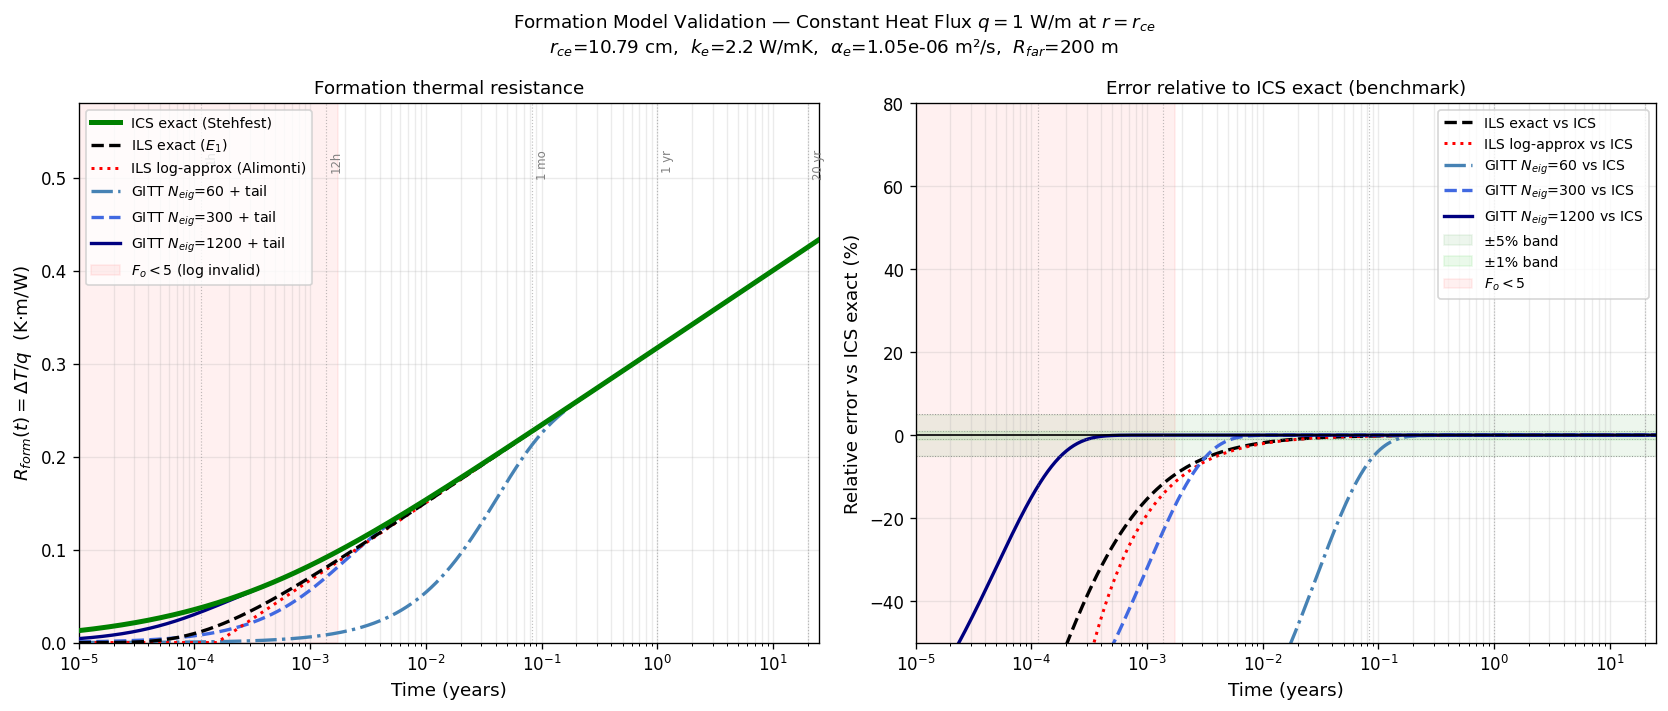


Figure saved: formation_model_comparison.png

  GITT N=  60: enters ±5% at 34 days,  ±1% at 53 days
  GITT N= 300: enters ±5% at 1 days,  ±1% at 2 days
  GITT N=1200: enters ±5% at 0 days,  ±1% at 0 days


In [ ]:
# ── Cell 15: Formation model validation — GITT vs ICS vs ILS ─────────────
# Constant q=1 W/m at r=rce. Pure formation resistance R(t)=DeltaT/q [K·m/W].
# No convective resistance, no coupling — isolated formation benchmark only.

from scipy.special import exp1, kv
from math import factorial as _fac
import warnings

print("=" * 62)
print("  FORMATION MODEL VALIDATION — constant q=1 W/m at r_ce")
print("=" * 62)
print(f"  rce={rce:.5f} m   ke={ke} W/mK   alpha_e={alpha_e:.3e} m²/s")
print(f"  Rfar={Rfar:.1f} m   R_ss=ln(Rfar/rce)/(2π ke) = "
      f"{np.log(Rfar/rce)/(2.*np.pi*ke):.5f} K·m/W")

# ── ILS exact ─────────────────────────────────────────────────────────────
def _R_ILS(t):
    return exp1(rce**2 / (4.*alpha_e*t)) / (4.*np.pi*ke)

# ── ILS log-approximation ─────────────────────────────────────────────────
def _R_ILS_log(t):
    arg = 4.*alpha_e*t / rce**2
    if arg <= 1.: return 0.
    return max((np.log(arg) - 0.5772) / (4.*np.pi*ke), 1e-12)

# ── ICS exact (Stehfest N=16) ─────────────────────────────────────────────
def _stehfest_V(N=16):
    V = np.zeros(N)
    for i in range(1, N+1):
        s = 0.
        for k in range(max(1, int((i+1)//2)), min(i, N//2)+1):
            s += (k**(N//2) * _fac(2*k) /
                  (_fac(N//2-k)*_fac(k)*_fac(k-1)*_fac(i-k)*_fac(2*k-i)))
        V[i-1] = (-1)**(i+N//2) * s
    return V
_V_st = _stehfest_V(16)

def _R_ICS(t):
    """ICS: T_bar(rce,s)/q = K0(xi)/(2π xi s ke K1(xi)).  Stehfest inversion."""
    F = 0.
    for i, Vi in enumerate(_V_st, 1):
        si = i * np.log(2.) / t
        xi = rce * np.sqrt(si / alpha_e)
        K0 = kv(0, xi);  K1 = kv(1, xi)
        if K1 < 1e-300: continue
        F += Vi * K0 / (2.*np.pi * xi * si * ke * K1)
    return np.log(2.) / t * F

# ── GITT with analytical tail correction ─────────────────────────────────
_R_ss_val = np.log(Rfar / rce) / (2.*np.pi*ke)

def _make_gitt(N_eig_val):
    """
    Build GITT R(t) function for given N_eig with tail correction.
    R(t) = R_partial(N_eig,t) + R_tail*(1 - exp(-t/tau_N))
    where R_tail = R_ss - partial_sum(N_eig)  [exact via steady-state identity].
    """
    print(f"  Computing GITT eigenvalues/norms for N={N_eig_val}...",
          end=" ", flush=True)
    (b, nm, p, _, _, tau_arr, _) = _get_gitt_arrays(
        N_eig_val, rce, Rfar, ke, alpha_e, dt_step)
    partial = np.sum(p**2 / (b**2 * nm)) / (2.*np.pi*ke)
    tail    = _R_ss_val - partial
    tau_N   = tau_arr[-1]   # slowest-decaying retained mode
    print(f"done.  partial={partial:.5f}  tail={tail:.5f}  "
          f"tau_N={tau_N/3600.:.1f} h")
    def R(t):
        decay  = np.exp(-alpha_e * b**2 * t)
        R_part = np.sum((1.-decay)*p**2/(b**2*nm)) / (2.*np.pi*ke)
        frac   = 1. - np.exp(-t / tau_N)
        return R_part + tail * frac
    return R

# Build GITT functions for three Neig values
_Neig_vals  = [60, 300, 1200]
_gitt_colors = ['steelblue', 'royalblue', 'navy']
_gitt_styles = ['-.', '--', '-']
_gitt_fns    = [_make_gitt(N) for N in _Neig_vals]

# ── Time array ────────────────────────────────────────────────────────────
_t_yr  = np.logspace(-5, np.log10(25.), 600)
_t_s   = _t_yr * 365.25 * t_day

print("\n  Evaluating ICS, ILS, log-approx...", end=" ", flush=True)
_R_ics  = np.array([_R_ICS(t)     for t in _t_s])
_R_ils  = np.array([_R_ILS(t)     for t in _t_s])
_R_log  = np.array([_R_ILS_log(t) for t in _t_s])
print("done.")
print("  Evaluating GITT variants...", end=" ", flush=True)
_R_gitts = [np.array([fn(t) for t in _t_s]) for fn in _gitt_fns]
print("done.")

_Fo   = alpha_e * _t_s / rce**2
_safe = _R_ics > 1e-8
def _rel(R): return np.where(_safe, 100.*(R - _R_ics)/_R_ics, np.nan)

# ── Summary table ─────────────────────────────────────────────────────────
_t_hl = np.array([1*3600., 6*3600., 12*3600., t_day,
                  7*t_day, 30*t_day, 91*t_day, 365*t_day, 20*365*t_day])
print()
hdr = f"  {'Time':<9}  {'Fo':>9}  {'R_ICS':>9}  {'R_ILS':>9}"
for N in _Neig_vals: hdr += f"  {'G'+str(N):>9}"
hdr += f"  {'ILS-ICS%':>9}"
for N in _Neig_vals: hdr += f"  {'G'+str(N)+'%':>8}"
print(hdr); print("  " + "-"*120)
for t in _t_hl:
    Fo=alpha_e*t/rce**2; ri=_R_ICS(t); rl=_R_ILS(t)
    lbl=f"{t/3600:.0f}h" if t<t_day else f"{t/t_day:.0f}d"
    row=f"  {lbl:<9}  {Fo:>9.2e}  {ri:>9.5f}  {rl:>9.5f}"
    for fn in _gitt_fns: row+=f"  {fn(t):>9.5f}"
    row+=f"  {100*(rl-ri)/ri:>+9.3f}%"
    for fn in _gitt_fns: row+=f"  {100*(fn(t)-ri)/ri:>+8.3f}%"
    print(row)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Formation Model Validation — Constant Heat Flux $q=1$ W/m at $r=r_{ce}$\n"
    f"$r_{{ce}}$={rce*100:.2f} cm,  $k_e$={ke} W/mK,  "
    f"$\\alpha_e$={alpha_e:.2e} m²/s,  $R_{{far}}$={Rfar:.0f} m",
    fontsize=11)

ax = axes[0]
ax.semilogx(_t_yr, _R_ics, 'g-',  lw=3,   zorder=6, label='ICS exact (Stehfest)')
ax.semilogx(_t_yr, _R_ils, 'k--', lw=2,   zorder=5, label='ILS exact ($E_1$)')
ax.semilogx(_t_yr, _R_log, 'r:',  lw=1.8, zorder=4, label='ILS log-approx (Alimonti)')
for R_g, N, col, ls in zip(_R_gitts, _Neig_vals, _gitt_colors, _gitt_styles):
    ax.semilogx(_t_yr, R_g, color=col, lw=2, ls=ls, zorder=3,
                label=f'GITT $N_{{eig}}$={N} + tail')
ax.fill_between(_t_yr, 0, 0.58, where=_Fo<5.,
                alpha=0.06, color='red', zorder=0, label='$F_o<5$ (log invalid)')
for tv, lbl in [(1./8766.,'1h'),(12./8766.,'12h'),
                (30./365.,'1 mo'),(1.,'1 yr'),(20.,'20 yr')]:
    ax.axvline(tv, color='gray', ls=':', lw=0.7, alpha=0.5)
    ax.text(tv*1.08, 0.53, lbl, fontsize=7, color='gray', rotation=90, va='top')
ax.set_xlabel('Time (years)', fontsize=11)
ax.set_ylabel('$R_{form}(t) = \Delta T/q$  (K·m/W)', fontsize=11)
ax.set_title('Formation thermal resistance', fontsize=11)
ax.legend(fontsize=8.5, loc='upper left')
ax.grid(True, which='both', alpha=0.25)
ax.set_xlim(_t_yr[0], _t_yr[-1]); ax.set_ylim(0., 0.58)

ax = axes[1]
ax.semilogx(_t_yr, _rel(_R_ils), 'k--', lw=2,   label='ILS exact vs ICS')
ax.semilogx(_t_yr, _rel(_R_log), 'r:',  lw=1.8, label='ILS log-approx vs ICS')
for R_g, N, col, ls in zip(_R_gitts, _Neig_vals, _gitt_colors, _gitt_styles):
    ax.semilogx(_t_yr, _rel(R_g), color=col, lw=2, ls=ls,
                label=f'GITT $N_{{eig}}$={N} vs ICS')
ax.axhline(0,  color='k',   lw=1.)
ax.axhline( 5, color='gray',lw=0.6, ls=':', alpha=0.8)
ax.axhline(-5, color='gray',lw=0.6, ls=':', alpha=0.8)
ax.axhline( 1, color='gray',lw=0.6, ls=':', alpha=0.6)
ax.axhline(-1, color='gray',lw=0.6, ls=':', alpha=0.6)
ax.fill_between(_t_yr, -5.,  5.,  alpha=0.07, color='green',     label='±5% band')
ax.fill_between(_t_yr, -1.,  1.,  alpha=0.10, color='limegreen', label='±1% band')
ax.fill_between(_t_yr, -80., 300., where=_Fo<5.,
                alpha=0.06, color='red', zorder=0, label='$F_o<5$')
for tv in [1./8766., 12./8766., 30./365., 1., 20.]:
    ax.axvline(tv, color='gray', ls=':', lw=0.7, alpha=0.5)
ax.set_xlabel('Time (years)', fontsize=11)
ax.set_ylabel('Relative error vs ICS exact (%)', fontsize=11)
ax.set_title('Error relative to ICS exact (benchmark)', fontsize=11)
ax.set_ylim(-50., 80.); ax.set_xlim(_t_yr[0], _t_yr[-1])
ax.legend(fontsize=8.5, loc='upper right')
ax.grid(True, which='both', alpha=0.25)

plt.tight_layout()
plt.savefig('formation_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure saved: formation_model_comparison.png")

# ── Convergence milestones ─────────────────────────────────────────────────
print()
for N, fn in zip(_Neig_vals, _gitt_fns):
    errs = np.array([abs(100.*(fn(t)-_R_ICS(t))/_R_ICS(t)) for t in _t_s[_safe]])
    idx_5 = np.where(errs < 5.)[0];  t_5 = _t_yr[_safe][idx_5[0]]*365.25 if len(idx_5) else np.nan
    idx_1 = np.where(errs < 1.)[0];  t_1 = _t_yr[_safe][idx_1[0]]*365.25 if len(idx_1) else np.nan
    print(f"  GITT N={N:4d}: enters ±5% at {t_5:.0f} days,  ±1% at {t_1:.0f} days")

## Cell 16 · Formation Model Comparison — GITT vs ICS vs ILS (coupled solver, 20 years)

Validates the GITT formation model against the ICS and ILS analytical solutions
in the context of the **coupled BVP solver** under the dynamic heat flux produced
by the 20-year cooling simulation. This complements Cell 15 (constant-flux benchmark)
by testing the formation model under realistic, time-varying forcing.

**Method.** The GITT coupled solver is run once (20 years, baseline parameters).
The annual-average heat flux profile $q_{\mathrm{eff}}(z)$ is stored for each year.
The ICS and ILS borehole wall temperatures are then computed via annual-step
superposition:

$$T_{\mathrm{bw}}^{\mathrm{ILS/ICS}}(z,\,t_N)
= T_\infty(z)
+ \sum_{k=0}^{N-1}
  \bigl[R_{\mathrm{form}}(t_N - t_k) - R_{\mathrm{form}}(t_N - t_{k+1})\bigr]
  \,\bar{q}_{\mathrm{eff},k}(z)$$

where $\bar{q}_{\mathrm{eff},k}(z)$ is the annual-average effective heat flux in
year $k$, $t_k = k$ years, and $R_{\mathrm{form}}(t)$ is either:

- **ILS:** $R_{\mathrm{form}}^{\mathrm{ILS}}(t) = \dfrac{1}{4\pi k_e}\,
  E_1\!\left(\dfrac{r_{ce}^2}{4\alpha_e t}\right)$

- **ICS:** $R_{\mathrm{form}}^{\mathrm{ICS}}(t)$ obtained by numerical inversion
  (Stehfest algorithm, $N=12$) of
  $\bar{R}(s) = \dfrac{K_0(\xi)}{2\pi k_e\,s\,\xi\,K_1(\xi)}$,
  $\xi = r_{ce}\sqrt{s/\alpha_e}$

The $T_{\mathrm{bw}}$ profile from each model is fed into the BVP solver to recover
$T_{\mathrm{ret}}$. No re-coupling is performed — this is a post-processing comparison.

**Expected behaviour.** ICS and ILS should agree to within 0.01 K at all years
(both are exact for an infinite medium at $F_o \gg 5$). GITT should sit slightly
above both at early years due to correct handling of the declining flux history,
converging to within 0.1 K by year 5 as the flux stabilises.


Running GITT coupled solver (20 yr) and accumulating annual q_eff...
  GITT done.  T_ret yr1=94.99 C  yr20=85.84 C
Computing ICS and ILS superposition... done.
  ICS  T_ret yr1=93.11 C  yr20=85.81 C
  ILS  T_ret yr1=93.12 C  yr20=85.81 C

 Year    T_GITT     T_ICS     T_ILS    GITT-ICS    GITT-ILS
----------------------------------------------------------
    1    94.989    93.106    93.115      1.8833      1.8739
    2    92.661    92.189    92.193      0.4728      0.4683
    5    89.784    89.633    89.635      0.1508      0.1490
   10    87.753    87.684    87.685      0.0684      0.0675
   15    86.619    86.575    86.576      0.0436      0.0430
   20    85.838    85.806    85.807      0.0318      0.0313


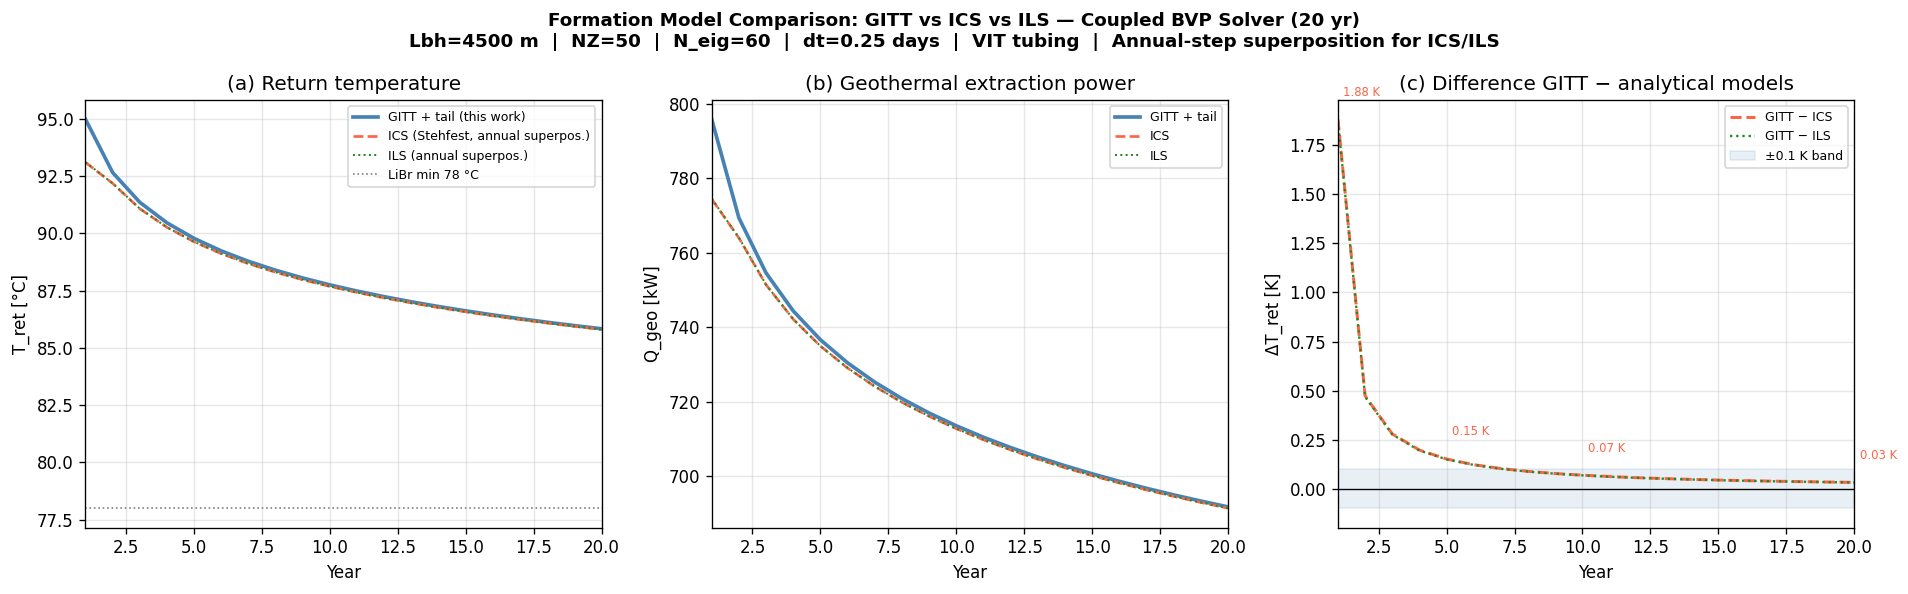

Figure saved: gitt_vs_ils_ics.png


In [ ]:
# ── Cell 16: GITT vs ICS vs ILS in the coupled solver (20-year comparison) ─
from scipy.special import exp1, k0 as _k0, k1 as _k1
from math import factorial as _fact

# ── Stehfest weights (N=12) ───────────────────────────────────────────────
def _stehfest_weights(N=12):
    V = np.zeros(N)
    for i in range(1, N+1):
        s = 0.
        for k2 in range(int((i+1)//2), min(i, N//2)+1):
            s += (k2**(N//2) * _fact(2*k2) /
                  (_fact(N//2-k2)*_fact(k2)*_fact(k2-1)*
                   _fact(i-k2)*_fact(2*k2-i)))
        V[i-1] = (-1)**(i+N//2) * s
    return V

_V_st = _stehfest_weights(12)

def R_ICS(t_sec):
    """ICS thermal resistance [m·K/W] via Stehfest inversion.
    Laplace transform: R_bar(s) = K0(xi)/(2*pi*ke*s*xi*K1(xi)),  xi=rce*sqrt(s/alpha_e).
    """
    if t_sec <= 0.: return 0.
    ln2_t = np.log(2.) / t_sec
    R_sum = 0.
    for i in range(12):
        s  = (i+1) * ln2_t
        xi = rce * np.sqrt(s / alpha_e)
        k0v = _k0(xi); k1v = _k1(xi)
        if xi * k1v < 1e-300: continue
        R_sum += _V_st[i] * k0v / (2.*np.pi*ke * s * xi * k1v)
    return max(R_sum * ln2_t, 0.)

def R_ILS(t_sec):
    """ILS thermal resistance [m·K/W].
    R(t) = E1(rce^2 / (4*alpha_e*t)) / (4*pi*ke).
    """
    if t_sec <= 0.: return 0.
    return exp1(rce**2 / (4.*alpha_e*t_sec)) / (4.*np.pi*ke)

# ── Step 1: run GITT coupled solver and store annual average q_eff ────────
print('Running GITT coupled solver (20 yr) and accumulating annual q_eff...')
_n_steps_c16 = int(n_years * 365.25 / n_days_per_step)
_spy_c16     = 365.25 / n_days_per_step   # steps per year
_n_yr        = n_years

_dz_m   = Lbh_default / NZ
_z_cc   = (np.arange(NZ) + 0.5) * _dz_m
_T_inf  = T_surf + Gg * _z_cc

# NTUs for baseline operating point
_pr     = water_props(min((Tin + T_surf + Gg * Lbh_default * 0.6) / 2., 95.))
_NTUat, _NTUbw, _mdot, _, _ = compute_NTUs(
    flow_rate_m3_h_demo, Lbh_default, _pr, kt_demo)
_G_eff  = _NTUbw * _mdot * _pr['cp'] / Lbh_default

# GITT arrays (baseline Neig, dt)
(_betas, _norms_g, _psi_rce, _inv_wts,
 _forc, _tau, _decay) = _get_gitt_arrays(
    Neig, rce, Rfar, ke, alpha_e, dt_step)
_R_ss     = np.log(Rfar / rce) / (2.*np.pi*ke)
_R_tail   = _R_ss - np.sum(_psi_rce**2 / (_betas**2 * _norms_g)) / (2.*np.pi*ke)
_b_next   = _betas[-1] + np.pi / Rfar
_d_tail   = np.exp(-alpha_e * _b_next**2 * dt_step)

_U_bar  = np.zeros((NZ, Neig))
_U_tail = np.zeros(NZ)
_Tbw    = _T_inf.copy()
_dT_sc  = max(_Tbw.max() - Tin, 1.)

def _cc16(th): return 0.5*(th[:-1]+th[1:])

_q_ann   = np.zeros((_n_yr, NZ))   # annual average q_eff [W/m]
_Tret_g  = np.zeros(_n_yr)
_Qgeo_g  = np.zeros(_n_yr)
_q_acc   = np.zeros(NZ); _st_acc = 0; _yr_i = 0
_sbin    = int(_spy_c16)   # steps per annual bin

for _mo in range(_n_steps_c16):
    _theta_bw = (_Tbw - Tin) / _dT_sc
    _ta, _ttb = solve_dbhe_bvp(_NTUat, _NTUbw, _theta_bw, NZ)
    _T_ret    = Tin + _ttb[0] * _dT_sc
    _T_a_cc   = Tin + _cc16(_ta) * _dT_sc
    _q_bw     = _G_eff * (_T_a_cc - _Tbw)
    _q_eff    = _q_bw * f_op
    _U_bar    = (_U_bar * _decay[np.newaxis, :]
                 + _forc[np.newaxis, :] * (1. - _decay[np.newaxis, :])
                 * _q_eff[:, np.newaxis])
    _U_tail   = _U_tail * _d_tail + _R_tail * (1. - _d_tail) * _q_eff
    _Tbw      = _T_inf + (_U_bar * _inv_wts[np.newaxis, :]).sum(axis=1) + _U_tail
    _dT_sc    = max(_Tbw.max() - Tin, 1.)
    _q_acc   += _q_eff; _st_acc += 1
    if (_mo+1) % _sbin == 0 and _yr_i < _n_yr:
        _q_ann[_yr_i]  = _q_acc / _st_acc
        _Tret_g[_yr_i] = _T_ret
        _Qgeo_g[_yr_i] = _mdot * _pr['cp'] * max(_T_ret - Tin, 0.)
        _q_acc[:] = 0.; _st_acc = 0; _yr_i += 1

print(f'  GITT done.  T_ret yr1={_Tret_g[0]:.2f} C  yr20={_Tret_g[-1]:.2f} C')

# ── Step 2: ICS / ILS superposition at each year ─────────────────────────
print('Computing ICS and ILS superposition...', end=' ', flush=True)
_t_bin  = 365.25 * t_day   # 1 year per bin [s]
_Tret_c = np.zeros(_n_yr); _Tret_l = np.zeros(_n_yr)
_Qgeo_c = np.zeros(_n_yr); _Qgeo_l = np.zeros(_n_yr)

def _Tbw_super(t_N_yr, R_func):
    """T_bw(z) at t_N_yr years via annual-step superposition."""
    Tbw_z = _T_inf.copy()
    for k in range(int(t_N_yr)):
        dR = R_func((t_N_yr - k)     * _t_bin) - \
             R_func((t_N_yr - k - 1) * _t_bin)
        Tbw_z += dR * _q_ann[k]
    return Tbw_z

for _yi in range(_n_yr):
    _tN = float(_yi + 1)
    for _Rfunc, _Tr, _Qr in [(R_ICS, _Tret_c, _Qgeo_c),
                              (R_ILS, _Tret_l, _Qgeo_l)]:
        _Tbw_loc = _Tbw_super(_tN, _Rfunc)
        _dsc_loc = max(_Tbw_loc.max() - Tin, 1.)
        _th_bw   = (_Tbw_loc - Tin) / _dsc_loc
        _ta_loc, _ttb_loc = solve_dbhe_bvp(_NTUat, _NTUbw, _th_bw, NZ)
        _Tr[_yi] = Tin + _ttb_loc[0] * _dsc_loc
        _Qr[_yi] = _mdot * _pr['cp'] * max(_Tr[_yi] - Tin, 0.)

print('done.')
print(f'  ICS  T_ret yr1={_Tret_c[0]:.2f} C  yr20={_Tret_c[-1]:.2f} C')
print(f'  ILS  T_ret yr1={_Tret_l[0]:.2f} C  yr20={_Tret_l[-1]:.2f} C')

# ── Results table ─────────────────────────────────────────────────────────
print()
print(f"{'Year':>5}  {'T_GITT':>8}  {'T_ICS':>8}  {'T_ILS':>8}  "
      f"{'GITT-ICS':>10}  {'GITT-ILS':>10}")
print('-' * 58)
for _yr in [1, 2, 5, 10, 15, 20]:
    _i = _yr - 1
    print(f"{_yr:>5}  {_Tret_g[_i]:>8.3f}  {_Tret_c[_i]:>8.3f}  {_Tret_l[_i]:>8.3f}  "
          f"{_Tret_g[_i]-_Tret_c[_i]:>10.4f}  {_Tret_g[_i]-_Tret_l[_i]:>10.4f}")

# ── Figure ────────────────────────────────────────────────────────────────
_t_yr = np.arange(1, _n_yr+1, dtype=float)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) T_ret
ax = axes[0]
ax.plot(_t_yr, _Tret_g, color='steelblue', lw=2.2, label='GITT + tail (this work)')
ax.plot(_t_yr, _Tret_c, color='tomato',    lw=1.6, ls='--', label='ICS (Stehfest, annual superpos.)')
ax.plot(_t_yr, _Tret_l, color='forestgreen', lw=1.2, ls=':', label='ILS (annual superpos.)')
ax.axhline(T_libr_min, color='gray', ls=':', lw=1., label=f'LiBr min {T_libr_min:.0f} °C')
ax.set_xlabel('Year'); ax.set_ylabel('T_ret [°C]')
ax.set_title('(a) Return temperature'); ax.legend(fontsize=7.5)
ax.grid(True, alpha=0.3); ax.set_xlim(1, 20)

# (b) Q_geo
ax = axes[1]
ax.plot(_t_yr, _Qgeo_g/1e3, color='steelblue', lw=2.2, label='GITT + tail')
ax.plot(_t_yr, _Qgeo_c/1e3, color='tomato',    lw=1.6, ls='--', label='ICS')
ax.plot(_t_yr, _Qgeo_l/1e3, color='forestgreen', lw=1.2, ls=':', label='ILS')
ax.set_xlabel('Year'); ax.set_ylabel('Q_geo [kW]')
ax.set_title('(b) Geothermal extraction power'); ax.legend(fontsize=7.5)
ax.grid(True, alpha=0.3); ax.set_xlim(1, 20)

# (c) Difference GITT - ICS and GITT - ILS
ax = axes[2]
ax.plot(_t_yr, _Tret_g - _Tret_c, color='tomato',    lw=1.8, ls='--', label='GITT − ICS')
ax.plot(_t_yr, _Tret_g - _Tret_l, color='forestgreen', lw=1.4, ls=':',  label='GITT − ILS')
ax.axhline(0., color='k', lw=0.8)
ax.fill_between(_t_yr, -0.1, 0.1, alpha=0.12, color='steelblue', label='±0.1 K band')
for _yr in [1, 5, 10, 20]:
    _i = _yr-1
    ax.annotate(f'{_Tret_g[_i]-_Tret_c[_i]:.2f} K',
                xy=(_yr, _Tret_g[_i]-_Tret_c[_i]),
                xytext=(_yr+0.2, _Tret_g[_i]-_Tret_c[_i]+0.12),
                fontsize=7, color='tomato')
ax.set_xlabel('Year'); ax.set_ylabel('ΔT_ret [K]')
ax.set_title('(c) Difference GITT − analytical models'); ax.legend(fontsize=7.5)
ax.grid(True, alpha=0.3); ax.set_xlim(1, 20)

plt.suptitle(
    f'Formation Model Comparison: GITT vs ICS vs ILS — Coupled BVP Solver (20 yr)\n'
    f'Lbh={Lbh_default:.0f} m  |  NZ={NZ}  |  N_eig={Neig}  |  '
    f'dt={n_days_per_step} days  |  VIT tubing  |  Annual-step superposition for ICS/ILS',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('gitt_vs_ils_ics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: gitt_vs_ils_ics.png')
